# 05 — FINAL FROZEN Results Synthesis: Flash Drought in Indonesia

This notebook is the **final visual/results synthesis layer** for the current thesis workflow.

It does **not** redetect flash drought and does **not** recompute ERA5-Land hourly data.

## Final source hierarchy used here

### Used as primary/final
- `03b`: **M2A** detection → `FD_BENCHMARK` (adapted literature-informed benchmark)
- `03d`: final benchmark climatology, 1996–2024
- `03e`: maximum-onset sensitivity, 4 vs 5 pentads
- `03f`: persistence sensitivity, 2 / 3 / 4 pentads below P20
- `03g`: percentile-construction sensitivity, EXACT / WIN1 / WIN2
- `04b FAST`: M2A year-block meteorological driver diagnostics

### Not mixed into the primary figures
- old Notebook 02 / early Notebook 03 `bbox_screening` products;
- `03c` legacy regional outputs whose `PRIMARY_METHOD` is **M1**; use the revised M2A regional notebook for final regional inference;
- old Notebook 04 all-event driver composite based on **M1 grid-cell starts**.

These older products remain useful for history/QC/regional exploratory work, but mixing them with an M2A benchmark would make the final Results internally inconsistent.

## Scientific interpretation rules

1. A **grid-cell event start is not an independent regional meteorological event**.
2. Binary P80/P90 hotspots mean **grid cells at or above the 80th/90th percentile of the valid-grid occurrence distribution**. They are not exact 20%/10% land-area classes and are not maps of “FD vs no FD”.
3. Exact hotspot footprints are expected to be more definition-sensitive than the continuous frequency field.
4. `onset_time` describes rapid P40→P20 development; `duration` describes the detected drought episode until recovery ≥P20.
5. P/T/VPD results are **physical-driver diagnostics / associations**, not causal attribution.
6. No independent SMAP validation is claimed. Use **detection, sensitivity, consistency, robustness**.

## Audited results already present in the uploaded notebooks

The completed runs show:

- valid Indonesia grid cells: **14,857**;
- M2A benchmark starts during 1996–2024: **559,676 grid-cell starts**;
- mean onset time: **1.72 pentads**; median = **2 pentads**;
- mean onset speed: **32.96 percentile points pentad⁻¹**;
- mean total detected episode duration: **7.65 pentads** (~38 d);
- mean initial P20 persistence: **5.93 pentads** (~30 d);
- top M2A years by maximum simultaneous drought-core area:
  **2003, 1997, 2015, 2014**;
- **no statistically significant monotonic trend was detected** in the three national annual FD-area metrics at p < 0.05;
- onset-window 4 vs 5 pentads is almost identical;
- persistence and percentile construction change event identity / exact ≥P90 occurrence hotspots more strongly,
  while their continuous spatial-frequency patterns remain highly correlated;
- rapid FD development is associated with **negative precipitation anomalies and elevated VPD**, with compound P-deficit + high-VPD conditions common but not universal.

The notebook below recomputes these summaries from the saved result files rather than relying on the text above.


### Final robustness status

- P80/P90 wording no longer implies exact land-area fractions.
- Trend wording is standardized to “no statistically significant monotonic trend was detected”.
- The final synthesis requires the independent 2003 peak sanity check to pass.
- Environment ABI/reproducibility QC is handled separately by `00_ENVIRONMENT_QC_AND_FREEZE.ipynb`.


### Decline-rate sensitivity now completed

The final 03h run provides the missing sensitivity dimension for the minimum
P40→P20 decline rate.

Observed results:

- RATE7.5: event count −1.29% relative to RATE5;
  event-start Jaccard = 0.987;
  spatial-frequency Spearman r = 0.9985;
  P90-hotspot Jaccard = 0.973.
- RATE10: event count −3.55% relative to RATE5;
  event-start Jaccard = 0.965;
  spatial-frequency Spearman r = 0.9953;
  P90-hotspot Jaccard = 0.895.

Therefore the **broad spatial pattern and event inventory are highly stable to
a substantially stricter decline-rate criterion**. Absolute event frequency
decreases slightly as expected, but the main spatial conclusion is retained.

These results are integrated below into the final robustness figure and the
cross-scenario hotspot agreement map.


## FINAL FREEZE STATUS

The core thesis workflow is now **frozen**.

Completed and accepted:
- M2A benchmark detection;
- final climatology;
- onset-window sensitivity;
- P20-persistence sensitivity;
- percentile-construction sensitivity;
- decline-rate sensitivity (5 / 7.5 / 10 pp pentad⁻¹);
- M2A regional/island rebuild;
- year/pentad driver-cube alignment QC;
- independent 2003 peak sanity check.

Verified QC results:
- 2003 independent peak = **P33, 81.419568% weighted drought-core area**;
- NumPy and xarray area calculations agree to ~1.4×10⁻14 percentage points;
- no active drought-core cells occur outside the valid Indonesia mask;
- every active 2003 peak drought-core cell has RZSM percentile <20;
- exact 04b year/pentad alignment passed from **1995 P01 to 2025 P73**;
- 04b final QC passed.

No additional methodological revision is required for the current thesis scope
unless a genuine runtime/data error is discovered.


In [1]:
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy import stats
from scipy import ndimage

warnings.filterwarnings("once")

# ============================================================
# PATHS
# ============================================================
BASE = Path(r"D:\ERA5_LAND")

CLIM_DIR = BASE / "output_fd_03d_paper_climatology"
DRIVER_DIR = BASE / "output_fd_04b_robust_drivers_fast"
ONSET_DIR = BASE / "output_fd_03e_onset_sensitivity"
PERSIST_DIR = BASE / "output_fd_03f_persistence_sensitivity"
PCT_DIR = BASE / "output_fd_03g_percentile_sensitivity"
RATE_DIR = BASE / "output_fd_03h_rate_sensitivity"
DET_DIR = BASE / "output_fd_03b_sensitivity"
QC2003_DIR = BASE / "output_fd_03i_qc_2003"

OUTPUT_DIR = BASE / "output_fd_05_final_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Optional administrative boundary from the earlier regional notebook.
PROVINCE_BOUNDARY_FILE = Path(
    r"D:\GIS\LapakGIS_Batas_Provinsi_2024.shp"
)

# ============================================================
# FINAL benchmark files
# ============================================================
DETECTION_FILE = DET_DIR / "fd_detection_M2A_1995_2025_indonesia.nc"
PERCENTILE_FILE = BASE / "output_rzsm" / "rzsm_percentile_gringorten_1995_2025.nc"

CLIM_NC = CLIM_DIR / "fd_benchmark_climatology_metrics_1996_2024.nc"
HOTSPOT_NC = CLIM_DIR / "fd_benchmark_hotspot_masks.nc"
SEASON_CSV = CLIM_DIR / "seasonal_monthly_onset_contribution.csv"
ANNUAL_CSV = CLIM_DIR / "annual_spatial_metrics_1996_2024.csv"
EVENT_SUMMARY_CSV = CLIM_DIR / "benchmark_event_characteristics_summary.csv"
TREND_CSV = CLIM_DIR / "annual_trend_screening.csv"
QC_2003_CSV = QC2003_DIR / "QC_2003_peak_summary.csv"

# Drivers
LAG_CSV = DRIVER_DIR / "year_block_onset_aligned_composite_bootstrap95.csv"
PHASE_CSV = DRIVER_DIR / "rapid_development_driver_states_bootstrap95.csv"
PHASE_YEAR_CSV = DRIVER_DIR / "rapid_development_driver_states_by_year.csv"
CORE_CSV = DRIVER_DIR / "drought_core_meteorology_bootstrap95.csv"
PRE_CSV = DRIVER_DIR / "preconditioning_summary.csv"

# Sensitivity summaries
ONSET_SUMMARY_CSV = ONSET_DIR / "onset_4_vs_5_summary.csv"
ONSET_CONSIST_CSV = ONSET_DIR / "onset_4_vs_5_spatial_consistency.csv"

PERSIST_SUMMARY_CSV = PERSIST_DIR / "persistence_2_3_4_summary.csv"
PERSIST_CONSIST_CSV = PERSIST_DIR / "persistence_spatial_consistency.csv"

PCT_AGREE_CSV = PCT_DIR / "percentile_method_agreement.csv"
PCT_SUMMARY_CSV = PCT_DIR / "percentile_method_detection_summary.csv"
PCT_CONSIST_CSV = PCT_DIR / "percentile_method_detection_consistency.csv"

# Decline-rate sensitivity
RATE_SUMMARY_CSV = RATE_DIR / "rate_5_7p5_10_summary.csv"
RATE_CONSIST_CSV = RATE_DIR / "rate_spatial_consistency.csv"
RATE_ANNUAL_CSV = RATE_DIR / "rate_5_7p5_10_annual_metrics.csv"

# Sensitivity detection files used for robust-hotspot agreement map
SCENARIO_FILES = {
    "M2A benchmark": DETECTION_FILE,
    "Onset ≤4": ONSET_DIR / "fd_robustness_onset4_persistence3.nc",
    "Persistence 2": PERSIST_DIR / "fd_robustness_onset5_persistence2.nc",
    "Persistence 4": PERSIST_DIR / "fd_robustness_onset5_persistence4.nc",
    "Percentile WIN1": PCT_DIR / "fd_robustness_percentile_WIN1_onset5_persist3.nc",
    "Percentile WIN2": PCT_DIR / "fd_robustness_percentile_WIN2_onset5_persist3.nc",
    "Decline rate 7.5": RATE_DIR / "fd_robustness_rate7p5_onset5_persist3.nc",
    "Decline rate 10": RATE_DIR / "fd_robustness_rate10p0_onset5_persist3.nc",
}

ANALYSIS_START = 1996
ANALYSIS_END = 2024
N_YEARS = ANALYSIS_END - ANALYSIS_START + 1

FIG_DPI = 300
INDO_EXTENT = [94.5, 141.5, -11.5, 6.5]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 10.5,
    "axes.titleweight": "bold",
})

# Warm palettes for FD intensity/occurrence maps.
CMAP_WARM = mpl.colormaps["YlOrRd"]
CMAP_RED = mpl.colormaps["Reds"]

# ============================================================
# Optional boundary engines
# ============================================================
HAS_GPD = False
HAS_CARTOPY = False
boundary_gdf = None

try:
    import geopandas as gpd
    HAS_GPD = True
except Exception:
    gpd = None

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
    HAS_CARTOPY = True
except Exception:
    HAS_CARTOPY = False

if HAS_GPD and PROVINCE_BOUNDARY_FILE.exists():
    try:
        boundary_gdf = gpd.read_file(PROVINCE_BOUNDARY_FILE).to_crs(4326)
        print("Boundary source: province shapefile")
    except Exception as exc:
        boundary_gdf = None
        print("Province boundary could not be loaded:", exc)

if boundary_gdf is None and HAS_CARTOPY:
    print("Boundary source: Cartopy coastline / country borders")
elif boundary_gdf is None:
    print("Boundary source: none; plain lon/lat fallback")


Boundary source: province shapefile


## 1. Preflight: only final-consistent outputs are allowed

The notebook stops if the final benchmark climatology, completed sensitivity tests,
or robust M2A driver outputs are missing.

This is deliberate: the final figure set should not silently fall back to an older M1 or bbox-screening result.


In [2]:
required_files = [
    DETECTION_FILE,
    PERCENTILE_FILE,
    CLIM_NC,
    HOTSPOT_NC,
    SEASON_CSV,
    ANNUAL_CSV,
    EVENT_SUMMARY_CSV,
    TREND_CSV,
    QC_2003_CSV,
    LAG_CSV,
    PHASE_CSV,
    PHASE_YEAR_CSV,
    CORE_CSV,
    PRE_CSV,
    ONSET_SUMMARY_CSV,
    ONSET_CONSIST_CSV,
    PERSIST_SUMMARY_CSV,
    PERSIST_CONSIST_CSV,
    PCT_AGREE_CSV,
    PCT_SUMMARY_CSV,
    PCT_CONSIST_CSV,
    RATE_SUMMARY_CSV,
    RATE_CONSIST_CSV,
    RATE_ANNUAL_CSV,
]

missing = [p for p in required_files if not p.exists()]

if missing:
    raise FileNotFoundError(
        "Final Notebook 05 requires these completed outputs:\n"
        + "\n".join(str(p) for p in missing)
    )

missing_scenarios = [
    f"{name}: {path}"
    for name, path in SCENARIO_FILES.items()
    if not path.exists()
]

if missing_scenarios:
    raise FileNotFoundError(
        "Robust-hotspot synthesis requires all sensitivity detection files:\n"
        + "\n".join(missing_scenarios)
    )

print("All final-consistent products are available.")


All final-consistent products are available.


## 2. Load final products and run internal consistency checks


In [3]:
clim = xr.open_dataset(CLIM_NC)
hot = xr.open_dataset(HOTSPOT_NC)

season = pd.read_csv(SEASON_CSV)
annual = pd.read_csv(ANNUAL_CSV)
event_summary = pd.read_csv(EVENT_SUMMARY_CSV)
trend = pd.read_csv(TREND_CSV)
qc_2003 = pd.read_csv(QC_2003_CSV)

lag = pd.read_csv(LAG_CSV)
phase = pd.read_csv(PHASE_CSV)
phase_year = pd.read_csv(PHASE_YEAR_CSV)
core = pd.read_csv(CORE_CSV)
antecedent = pd.read_csv(PRE_CSV)

onset_summary = pd.read_csv(ONSET_SUMMARY_CSV)
onset_consist = pd.read_csv(ONSET_CONSIST_CSV)

persist_summary = pd.read_csv(PERSIST_SUMMARY_CSV)
persist_consist = pd.read_csv(PERSIST_CONSIST_CSV)

pct_agree = pd.read_csv(PCT_AGREE_CSV)
pct_summary = pd.read_csv(PCT_SUMMARY_CSV)
pct_consist = pd.read_csv(PCT_CONSIST_CSV)

rate_summary = pd.read_csv(RATE_SUMMARY_CSV)
rate_consist = pd.read_csv(RATE_CONSIST_CSV)
rate_annual = pd.read_csv(RATE_ANNUAL_CSV)

det = xr.open_dataset(
    DETECTION_FILE,
    chunks={"time_index": 73},
    mask_and_scale=False,
)

valid = (det["valid_grid_mask"] == 1).compute()

year_all = np.asarray(det["year"].values, dtype=int)
analysis_idx = np.flatnonzero(
    (year_all >= ANALYSIS_START)
    & (year_all <= ANALYSIS_END)
)

if analysis_idx.size != N_YEARS * 73:
    raise ValueError(
        f"Expected {N_YEARS*73} pentads for {ANALYSIS_START}-{ANALYSIS_END}; "
        f"found {analysis_idx.size}."
    )

d = det.isel(time_index=analysis_idx)

n_valid = int(valid.sum().item())
if n_valid != 14857:
    print(
        f"NOTE: valid grid count is {n_valid}; "
        "the audited run contained 14,857 grids."
    )

if not (event_summary["n_gridcell_events"] == event_summary["n_gridcell_events"].iloc[0]).all():
    raise ValueError("Event-characteristic table contains inconsistent event counts.")

benchmark_event_count = int(event_summary["n_gridcell_events"].iloc[0])

# Dynamic top years: no hard-coded 2004/2014 ambiguity.
top_years = (
    annual.nlargest(4, "maximum_drought_core_area_percent")
    [["year", "maximum_drought_core_area_percent", "pentad_of_maximum_core_area"]]
    .reset_index(drop=True)
)

print("Valid Indonesia grids:", n_valid)
print("Benchmark grid-cell starts:", f"{benchmark_event_count:,}")
print("\nTop four benchmark years by maximum simultaneous drought-core area:")
display(top_years)


if len(qc_2003) != 1:
    raise ValueError(
        "QC_2003_peak_summary.csv must contain exactly one summary row."
    )

if not bool(qc_2003["overall_pass"].iloc[0]):
    raise RuntimeError(
        "Independent 2003 national peak sanity check did not pass. "
        "Do not freeze the final Results notebook."
    )

print(
    "Independent 2003 peak QC: PASS |",
    "P%02d" % int(qc_2003["independent_peak_pentad"].iloc[0]),
    "| weighted core area = %.6f%%"
    % float(qc_2003["independent_weighted_core_area_percent"].iloc[0]),
)


# ------------------------------------------------------------
# Final 03h decline-rate robustness QC
# ------------------------------------------------------------
required_rate_methods = {
    "RATE5_BASELINE",
    "RATE7P5",
    "RATE10",
}

if set(rate_summary["method"]) != required_rate_methods:
    raise ValueError(
        "03h decline-rate summary does not contain exactly "
        "RATE5_BASELINE, RATE7P5, and RATE10."
    )

for variant in ["RATE7P5", "RATE10"]:
    if variant not in set(rate_consist["variant"]):
        raise ValueError(
            f"Missing 03h spatial-consistency row for {variant}."
        )

rate7 = rate_consist.loc[
    rate_consist["variant"] == "RATE7P5"
].iloc[0]

rate10 = rate_consist.loc[
    rate_consist["variant"] == "RATE10"
].iloc[0]

print(
    "03h rate sensitivity loaded:",
    f"RATE7.5 freq-r={rate7['frequency_spearman_r']:.4f}, "
    f"P90-J={rate7['q90_hotspot_jaccard']:.3f}; "
    f"RATE10 freq-r={rate10['frequency_spearman_r']:.4f}, "
    f"P90-J={rate10['q90_hotspot_jaccard']:.3f}"
)


<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


Valid Indonesia grids: 14857
Benchmark grid-cell starts: 559,676

Top four benchmark years by maximum simultaneous drought-core area:


,year,maximum_drought_core_area_percent,pentad_of_maximum_core_area
0,2003,81.419568,33
1,1997,69.897383,32
2,2015,69.548994,39
3,2014,55.171887,8


Independent 2003 peak QC: PASS | P33 | weighted core area = 81.419568%
03h rate sensitivity loaded: RATE7.5 freq-r=0.9985, P90-J=0.973; RATE10 freq-r=0.9953, P90-J=0.895


### Audit note: which older outputs are deliberately excluded?

- `03c` was built with `PRIMARY_METHOD = M1`; therefore its macro-island climatology is **not** inserted into the main M2A figures.
- old Notebook 04 used an all-event M1 composite with hundreds of thousands of grid-cell starts; the final driver figures use the M2A **year-block** result from 04b instead.
- 2004 is useful as a regional/sensitivity comparison year, but the final M2A national top four are determined dynamically from 03d. In the audited run they are **2003, 1997, 2015, 2014**.


### Decline-rate sensitivity: completed

The final `03h` run is now part of the robustness assessment.

| Variant | Event-count change | Event-start Jaccard | Spatial-frequency Spearman r | P90-hotspot Jaccard |
|---|---:|---:|---:|---:|
| RATE7.5 | −1.29% | 0.987 | 0.9985 | 0.973 |
| RATE10 | −3.55% | 0.965 | 0.9953 | 0.895 |

**Interpretation:** making the minimum decline criterion substantially stricter
slightly reduces absolute frequency, but preserves the event inventory, broad
spatial-frequency field, and upper-tail hotspot structure to a high degree.

Thus, among the tested definition components, **persistence and percentile
construction are more influential for the exact P90 hotspot footprint than the
decline-rate threshold**.


## 3. Build a manuscript-ready numerical summary


In [4]:
def event_stat(variable, stat="mean"):
    row = event_summary.loc[event_summary["variable"] == variable].iloc[0]
    return float(row[stat])

def phase_metric(name):
    row = phase.loc[phase["metric"] == name].iloc[0]
    return float(row["mean"]), float(row["ci95_low"]), float(row["ci95_high"])

def lag_metric(variable, lag_value):
    return lag.loc[
        (lag["variable"] == variable)
        & (lag["lag"] == int(lag_value))
    ].iloc[0]

peak_month_row = season.loc[season["contribution_percent"].idxmax()]
peak_month = int(peak_month_row["month"])
peak_month_share = float(peak_month_row["contribution_percent"])

trend_any_sig = bool((trend["p_value"] < 0.05).any())

p_lag1 = lag_metric("tp_anom_mm", 1)
t_lag1 = lag_metric("t2m_anom_c", 1)
v_lag1 = lag_metric("vpd_anom_kpa", 1)

zp = phase_metric("mean_z_precip")
zt = phase_metric("mean_z_t2m")
zv = phase_metric("mean_z_vpd")

fp = phase_metric("strong_precip_deficit_fraction")
fv = phase_metric("high_vpd_fraction")
fc = phase_metric("compound_pdef_highvpd_fraction")
fe = phase_metric("either_pdef_or_highvpd_fraction")

core_lookup = core.set_index("variable")

summary_rows = [
    ("Valid Indonesia grids", n_valid, "grid cells"),
    ("Independent 2003 peak QC passed", bool(qc_2003["overall_pass"].iloc[0]), "boolean"),
    ("Independent 2003 peak area", float(qc_2003["independent_weighted_core_area_percent"].iloc[0]), "%"),
    ("M2A grid-cell starts, 1996–2024", benchmark_event_count, "grid-cell starts"),
    ("Mean onset time", event_stat("onset_time_pentads_at_start"), "pentads"),
    ("Median onset time", event_stat("onset_time_pentads_at_start", "median"), "pentads"),
    ("Mean onset speed", event_stat("onset_speed_at_start"), "pp pentad-1"),
    ("Mean detected episode duration", event_stat("duration_pentads_at_start"), "pentads"),
    ("Mean initial P20 persistence", event_stat("below_p20_pentads_at_start"), "pentads"),
    ("Median minimum RZSM percentile", event_stat("minimum_percentile_at_start", "median"), "percentile"),
    ("Peak national onset-contribution month", peak_month, "month number"),
    ("Peak month contribution", peak_month_share, "%"),
    ("Any annual FD-area trend p<0.05?", trend_any_sig, "boolean"),
    ("Rapid-phase mean standardized P", zp[0], "z"),
    ("Rapid-phase mean standardized T2m", zt[0], "z"),
    ("Rapid-phase mean standardized VPD", zv[0], "z"),
    ("Strong P-deficit fraction", fp[0] * 100, "%"),
    ("High-VPD fraction", fv[0] * 100, "%"),
    ("Compound P-deficit + high-VPD", fc[0] * 100, "%"),
    ("Either strong P-deficit or high VPD", fe[0] * 100, "%"),
    (
        "RATE7.5 event-count change vs RATE5",
        float(
            rate_summary.loc[
                rate_summary["method"] == "RATE7P5",
                "event_count_change_percent_vs_RATE5",
            ].iloc[0]
        ),
        "%",
    ),
    (
        "RATE10 event-count change vs RATE5",
        float(
            rate_summary.loc[
                rate_summary["method"] == "RATE10",
                "event_count_change_percent_vs_RATE5",
            ].iloc[0]
        ),
        "%",
    ),
    (
        "RATE7.5 spatial-frequency r",
        float(rate7["frequency_spearman_r"]),
        "Spearman r",
    ),
    (
        "RATE10 spatial-frequency r",
        float(rate10["frequency_spearman_r"]),
        "Spearman r",
    ),
]

summary_table = pd.DataFrame(
    summary_rows,
    columns=["result", "value", "unit"],
)

summary_table.to_csv(
    OUTPUT_DIR / "Table0_core_results_summary.csv",
    index=False,
)

display(summary_table)

print("\nDrought-core meteorology (year-block mean ± bootstrap CI):")
display(core)


,result,value,unit
0,Valid Indonesia grids,14857,grid cells
1,Independent 2003 peak QC passed,True,boolean
2,Independent 2003 peak area,81.419568,%
3,"M2A grid-cell starts, 1996–2024",559676,grid-cell starts
4,Mean onset time,1.720956,pentads
5,Median onset time,2.0,pentads
6,Mean onset speed,32.961132,pp pentad-1
7,Mean detected episode duration,7.648331,pentads
8,Mean initial P20 persistence,5.927374,pentads
9,Median minimum RZSM percentile,5.012854,percentile



Drought-core meteorology (year-block mean ± bootstrap CI):


,variable,mean,ci95_low,ci95_high,n_year_blocks
0,tp_anom_mm,-19.221886,-19.846896,-18.623585,29
1,t2m_anom_c,0.367172,0.271979,0.465196,29
2,d2m_anom_c,-0.315384,-0.416545,-0.205277,29
3,vpd_anom_kpa,0.122986,0.110073,0.137514,29


## 4. Mapping helpers

Priority for boundaries:

1. your Indonesian province shapefile, if available;
2. Cartopy coastline/country borders;
3. plain lon/lat fallback.

Cartopy `Gridliner` is deliberately **not used**, avoiding the GEOS error encountered previously.


In [5]:
def nice_ticks(lo, hi):
    span = hi - lo
    if span <= 8:
        step = 2
    elif span <= 20:
        step = 5
    else:
        step = 10

    a = np.ceil(lo / step) * step
    b = np.floor(hi / step) * step

    if b < a:
        return np.array([(lo + hi) / 2])

    return np.arange(a, b + 0.1 * step, step)


def setup_map_ax(fig, position, extent=INDO_EXTENT):
    if boundary_gdf is not None:
        ax = fig.add_subplot(position)
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        ax.set_xticks(nice_ticks(extent[0], extent[1]))
        ax.set_yticks(nice_ticks(extent[2], extent[3]))
        ax.grid(True, color="0.88", linestyle="--", linewidth=0.4, zorder=0)
        return ax

    if HAS_CARTOPY:
        ax = fig.add_subplot(position, projection=ccrs.PlateCarree())
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.coastlines(resolution="50m", linewidth=0.7, color="black", zorder=20)
        ax.add_feature(
            cfeature.BORDERS.with_scale("50m"),
            linewidth=0.4,
            edgecolor="0.3",
            zorder=19,
        )

        xt = nice_ticks(extent[0], extent[1])
        yt = nice_ticks(extent[2], extent[3])

        ax.set_xticks(xt, crs=ccrs.PlateCarree())
        ax.set_yticks(yt, crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter(degree_symbol="°"))
        ax.yaxis.set_major_formatter(LatitudeFormatter(degree_symbol="°"))
        ax.grid(True, color="0.88", linestyle="--", linewidth=0.4, zorder=0)
        return ax

    ax = fig.add_subplot(position)
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_xticks(nice_ticks(extent[0], extent[1]))
    ax.set_yticks(nice_ticks(extent[2], extent[3]))
    ax.grid(True, color="0.88", linestyle="--", linewidth=0.4, zorder=0)
    return ax


def overlay_indonesia_boundary(ax, province_lines=False):
    if boundary_gdf is not None:
        if province_lines:
            boundary_gdf.boundary.plot(
                ax=ax,
                color="black",
                linewidth=0.35,
                zorder=30,
            )
        else:
            try:
                outer = boundary_gdf.dissolve()
                outer.boundary.plot(
                    ax=ax,
                    color="black",
                    linewidth=0.8,
                    zorder=30,
                )
            except Exception:
                boundary_gdf.boundary.plot(
                    ax=ax,
                    color="black",
                    linewidth=0.5,
                    zorder=30,
                )


def map_mesh(ax, da, cmap=CMAP_WARM, vmin=None, vmax=None, norm=None, zorder=2):
    if HAS_CARTOPY and boundary_gdf is None:
        return ax.pcolormesh(
            da["longitude"],
            da["latitude"],
            da,
            shading="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            norm=norm,
            transform=ccrs.PlateCarree(),
            zorder=zorder,
        )

    return ax.pcolormesh(
        da["longitude"],
        da["latitude"],
        da,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        norm=norm,
        zorder=zorder,
    )


def map_contour(ax, da, level=0.5, color="black", linewidth=1.0, linestyle="-"):
    if HAS_CARTOPY and boundary_gdf is None:
        return ax.contour(
            da["longitude"],
            da["latitude"],
            da.values,
            levels=[level],
            colors=[color],
            linewidths=linewidth,
            linestyles=linestyle,
            transform=ccrs.PlateCarree(),
            zorder=35,
        )

    return ax.contour(
        da["longitude"],
        da["latitude"],
        da.values,
        levels=[level],
        colors=[color],
        linewidths=linewidth,
        linestyles=linestyle,
        zorder=35,
    )


def panel_label(ax, label):
    ax.text(
        0.012, 0.985, label,
        transform=ax.transAxes,
        ha="left", va="top",
        fontweight="bold",
        fontsize=11,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
        zorder=50,
    )


def safe_savefig(fig, filename):
    path = OUTPUT_DIR / filename

    try:
        fig.savefig(
            path,
            dpi=FIG_DPI,
            bbox_inches="tight",
            facecolor="white",
        )
    except Exception as exc:
        msg = str(exc)
        if (
            "GEOSException" in type(exc).__name__
            or "LinearRing" in msg
            or "closed linestring" in msg
        ):
            print("Geometry warning; retrying without tight bbox:", exc)
            fig.savefig(path, dpi=FIG_DPI, facecolor="white")
        else:
            raise

    print("Saved:", path)


# Figure 1 — Benchmark flash-drought climatology

This is the core spatial-result figure.

The panels separate **how often**, **how fast**, and **how severe/long** the detected events are.
A warm color means a larger value of the variable shown; it does not automatically mean higher temperature.


C:\Users\User\AppData\Local\Temp\ipykernel_13660\1375124127.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.92, 0.96])


Saved: D:\ERA5_LAND\output_fd_05_final_results\Figure1_benchmark_climatology_normalized.png


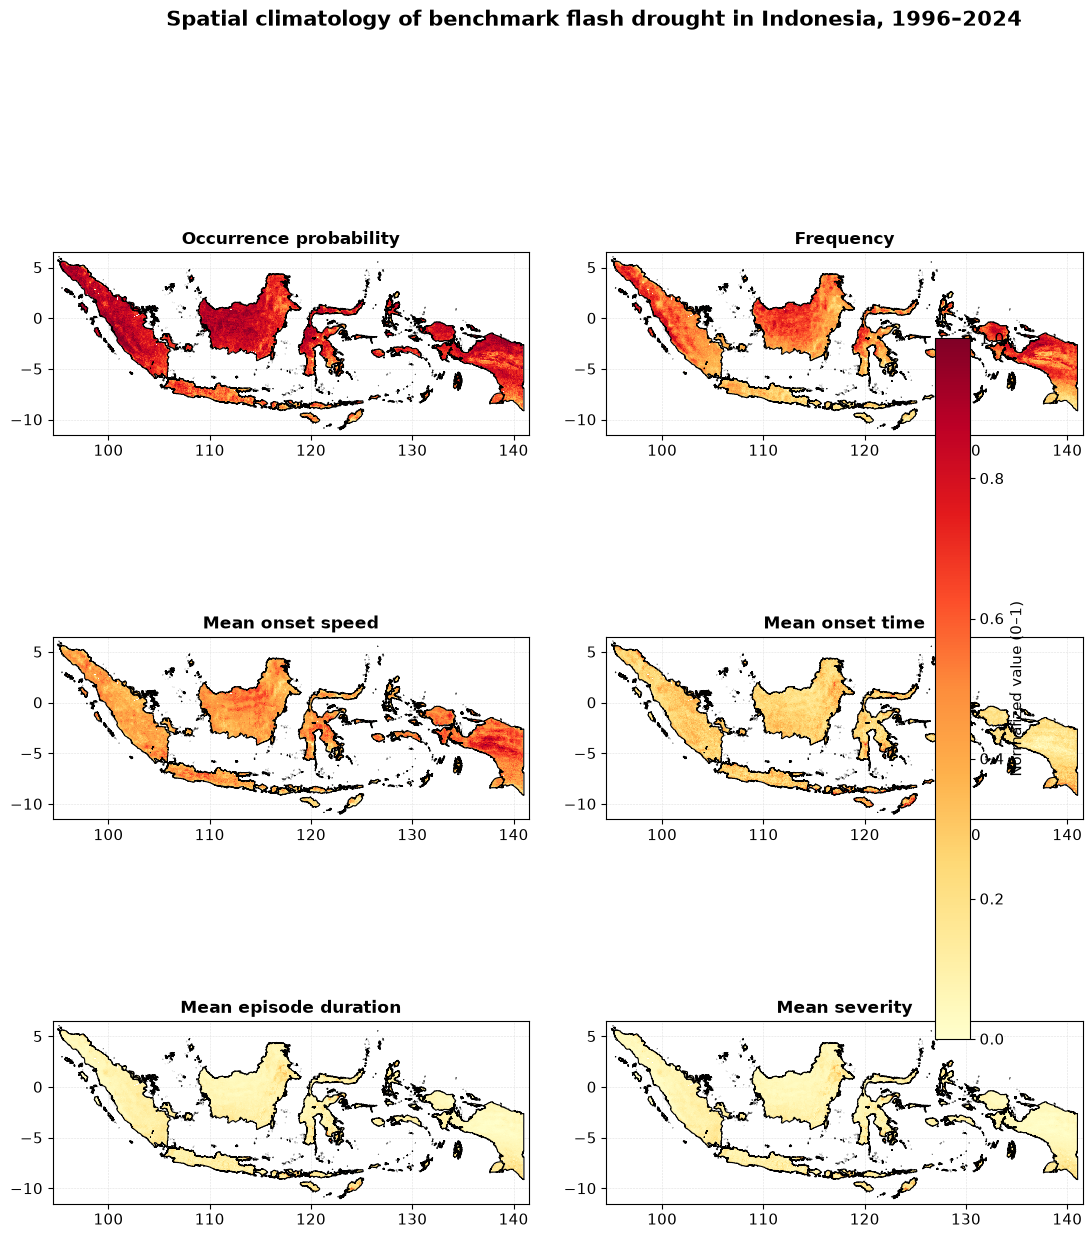

In [24]:
fig = plt.figure(figsize=(12, 14))

panels = [
    ("occurrence_probability_percent", "Occurrence probability"),
    ("events_per_decade", "Frequency"),
    ("mean_onset_speed_pp_per_pentad", "Mean onset speed"),
    ("mean_onset_time_pentads", "Mean onset time"),
    ("mean_total_duration_days", "Mean episode duration"),
    ("mean_severity_p40_pp_pentad", "Mean severity"),
]

positions = [321, 322, 323, 324, 325, 326]
axes = []

for pos, (var, title) in zip(positions, panels):
    ax = setup_map_ax(fig, pos)

    x = clim[var]
    x_norm = (x - x.min()) / (x.max() - x.min())

    im = map_mesh(ax, x_norm, cmap=CMAP_WARM, vmin=0, vmax=1)
    overlay_indonesia_boundary(ax)

    ax.set_title(title, fontweight="bold")
    axes.append(ax)

cb = fig.colorbar(im, ax=axes, shrink=0.65, pad=0.03)
cb.set_label("Normalized value (0–1)")

fig.suptitle(
    "Spatial climatology of benchmark flash drought in Indonesia, 1996–2024",
    fontsize=15, fontweight="bold"
)

fig.tight_layout(rect=[0, 0, 0.92, 0.96])
safe_savefig(fig, "Figure1_benchmark_climatology_normalized.png")
plt.show()

TypeError: safe_savefig() got an unexpected keyword argument 'dpi'

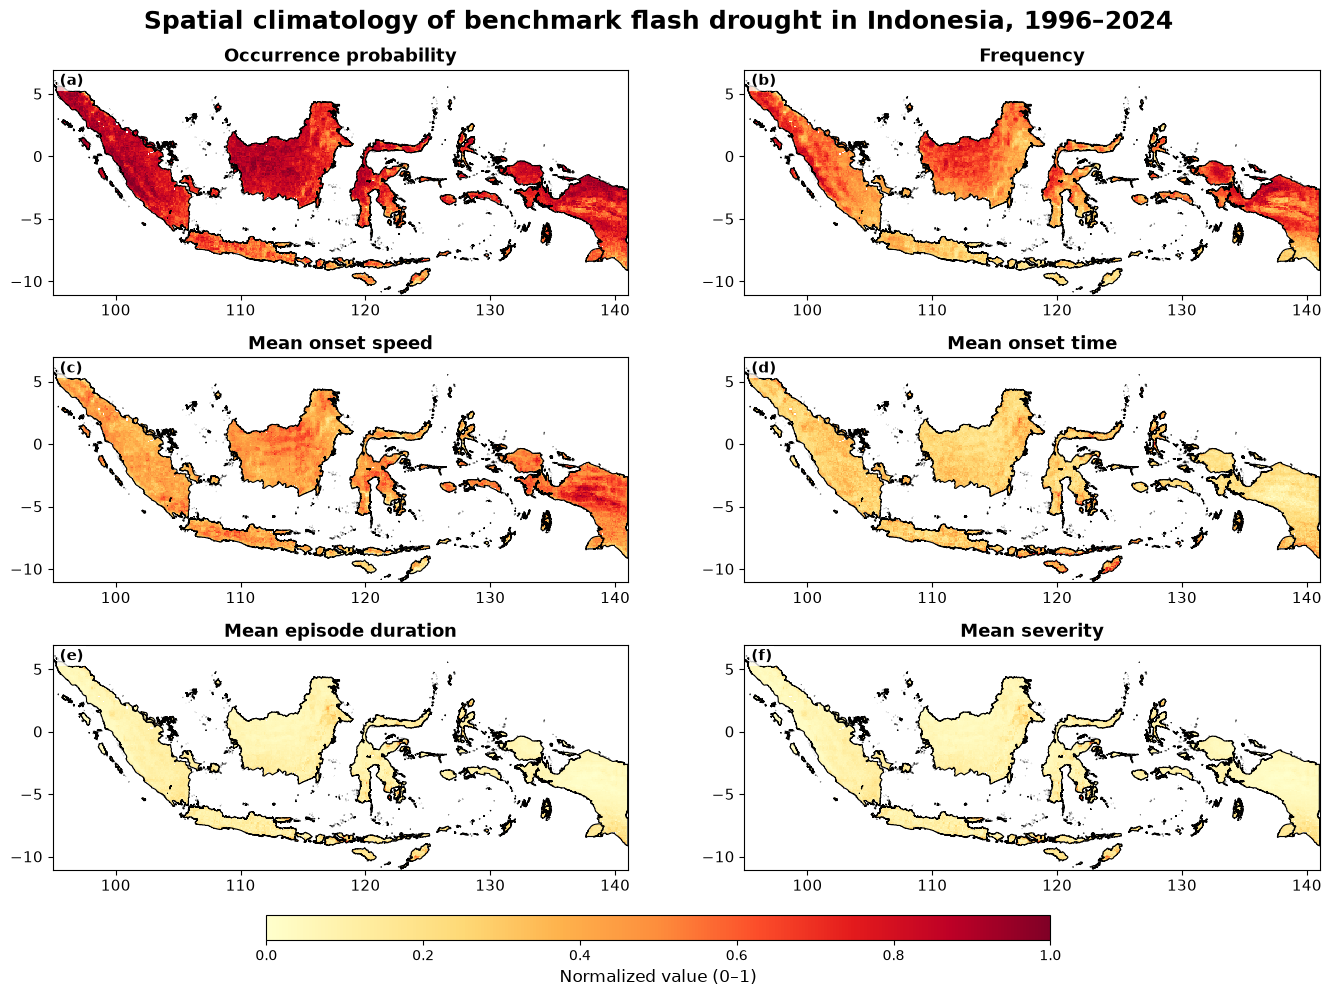

In [6]:
fig, axs = plt.subplots(3, 2, figsize=(14, 10))
axs = axs.ravel()

panels = [
    ("occurrence_probability_percent", "Occurrence probability", "a"),
    ("events_per_decade", "Frequency", "b"),
    ("mean_onset_speed_pp_per_pentad", "Mean onset speed", "c"),
    ("mean_onset_time_pentads", "Mean onset time", "d"),
    ("mean_total_duration_days", "Mean episode duration", "e"),
    ("mean_severity_p40_pp_pentad", "Mean severity", "f"),
]

for ax, (var, title, letter) in zip(axs, panels):
    x = clim[var]
    x_norm = (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x))

    im = map_mesh(ax, x_norm, cmap=CMAP_WARM, vmin=0, vmax=1)
    overlay_indonesia_boundary(ax)

    ax.set_title(title, fontsize=13, fontweight="bold")
    panel_label(ax, f"({letter})")

fig.suptitle(
    "Spatial climatology of benchmark flash drought in Indonesia, 1996–2024",
    fontsize=18, fontweight="bold", y=0.98
)

# kasih ruang bawah khusus untuk colorbar
fig.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.12,
                    wspace=0.16, hspace=0.28)

# colorbar horizontal di bawah, tidak menimpa peta
cax = fig.add_axes([0.22, 0.05, 0.56, 0.025])  # [left, bottom, width, height]
cb = fig.colorbar(im, cax=cax, orientation="horizontal")
cb.set_label("Normalized value (0–1)", fontsize=12)
cb.ax.tick_params(labelsize=10)

safe_savefig(fig, "Figure1_benchmark_climatology_normalized_HD.png", dpi=600)
plt.show()

Saved: D:\ERA5_LAND\output_fd_05_final_results\Figure1_benchmark_climatology.png


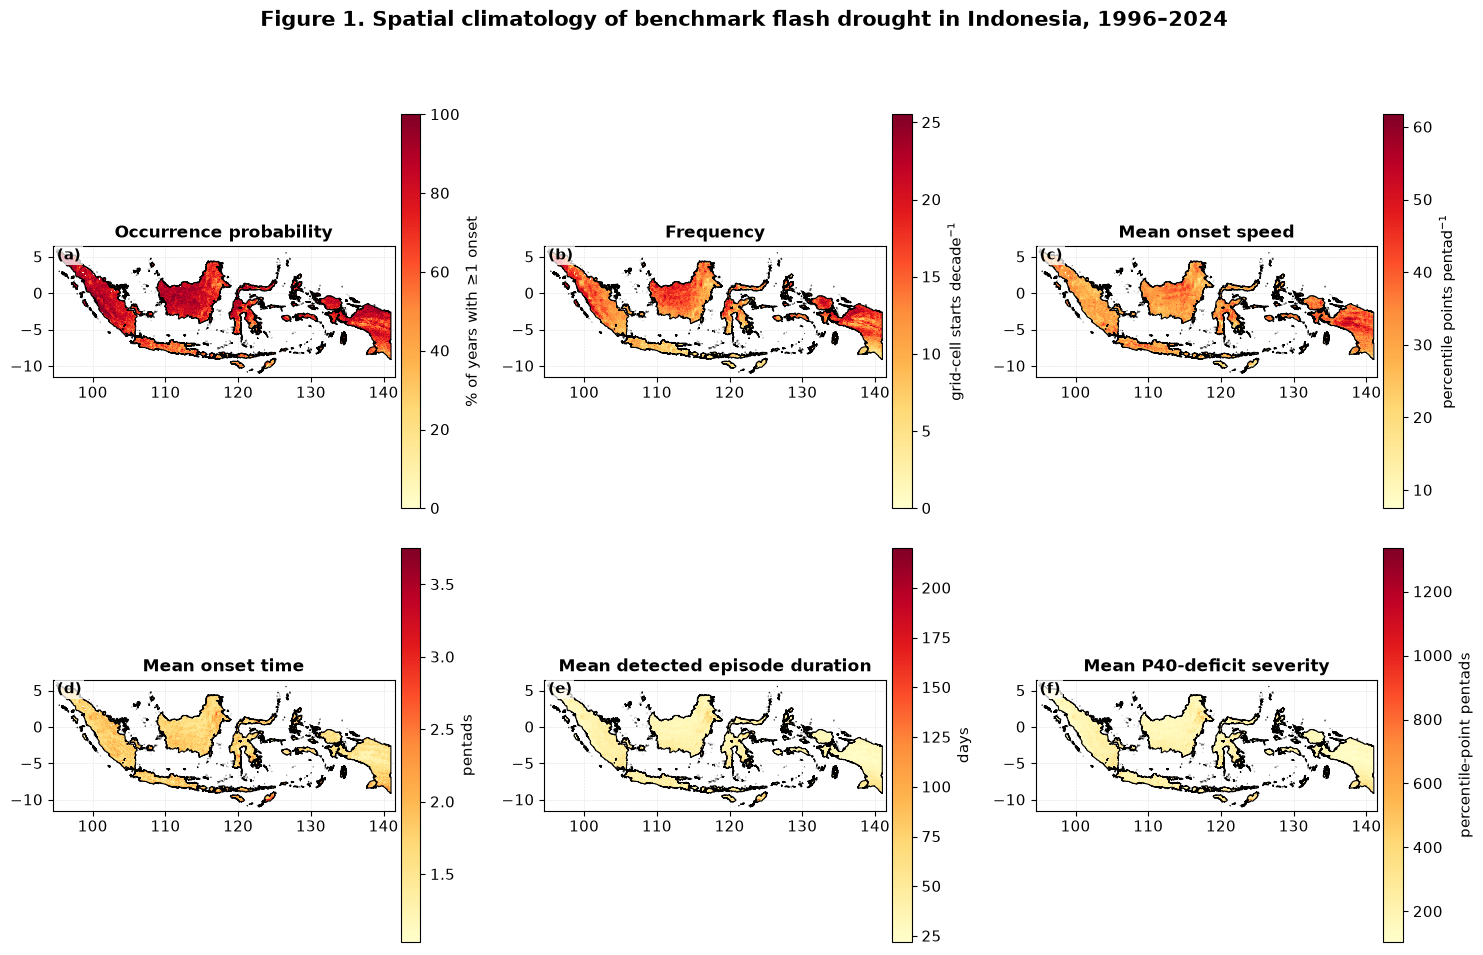

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

fig = plt.figure(figsize=(13, 14))

panels = [
    ("occurrence_probability_percent", "Occurrence probability", "a"),
    ("events_per_decade", "Frequency", "b"),
    ("mean_onset_speed_pp_per_pentad", "Mean onset speed", "c"),
    ("mean_onset_time_pentads", "Mean onset time", "d"),
    ("mean_total_duration_days", "Mean episode duration", "e"),
    ("mean_severity_p40_pp_pentad", "Mean severity", "f"),
]

positions = [321, 322, 323, 324, 325, 326]
axes = []

for pos, (var, title, letter) in zip(positions, panels):
    ax = setup_map_ax(fig, pos)

    x = clim[var]
    xmin = np.nanmin(x)
    xmax = np.nanmax(x)
    x_norm = (x - xmin) / (xmax - xmin)

    im = map_mesh(ax, x_norm, cmap=CMAP_WARM, vmin=0, vmax=1)
    overlay_indonesia_boundary(ax)

    ax.set_title(title, fontsize=15, fontweight="bold")
    panel_label(ax, f"({letter})")
    axes.append(ax)

fig.suptitle(
    "Spatial climatology of benchmark flash drought in Indonesia, 1996–2024",
    fontsize=20, fontweight="bold", y=0.98
)

# kasih ruang bawah khusus buat colorbar
fig.subplots_adjust(left=0.06, right=0.98, top=0.93, bottom=0.13,
                    wspace=0.16, hspace=0.22)

# 1 colorbar horizontal di bawah
cax = fig.add_axes([0.22, 0.06, 0.56, 0.022])  # [left, bottom, width, height]
sm = ScalarMappable(norm=Normalize(0, 1), cmap=CMAP_WARM)
sm.set_array([])

cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
cb.set_label("Normalized value (0–1)", fontsize=13)
cb.ax.tick_params(labelsize=11)

# simpan HD untuk paper
fig.savefig("Figure1_benchmark_climatology_normalized_HD.png",
            dpi=600, bbox_inches="tight", facecolor="white")

plt.show()

# Figure 2 — Seasonality, interannual variability, and top years

The annual peak is the **maximum simultaneous fraction of valid Indonesian land grid in the P20 drought core**, not a count of independent regional drought systems.

The top years are computed dynamically from the final M2A climatology.


Saved: D:\ERA5_LAND\output_fd_05_final_results\Figure2_temporal_characteristics.png


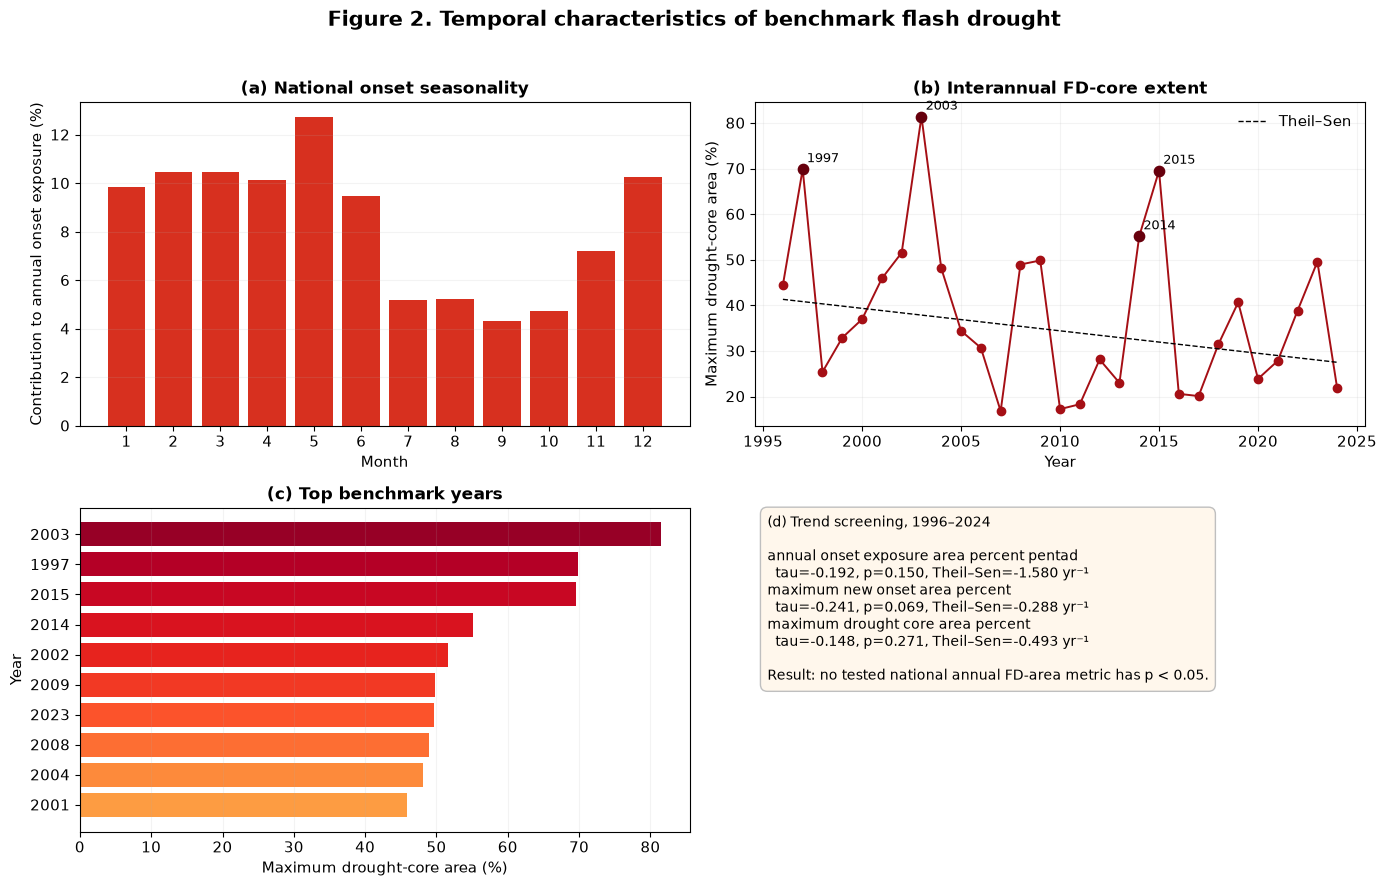

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) Monthly onset contribution
axes[0, 0].bar(
    season["month"],
    season["contribution_percent"],
    color="#d7301f",
)
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set(
    xlabel="Month",
    ylabel="Contribution to annual onset exposure (%)",
    title="(a) National onset seasonality",
)
axes[0, 0].grid(axis="y", alpha=0.15)

# (b) Annual max core area
axes[0, 1].plot(
    annual["year"],
    annual["maximum_drought_core_area_percent"],
    marker="o",
    color="#a50f15",
    linewidth=1.4,
)

x = annual["year"].to_numpy(dtype=float)
y = annual["maximum_drought_core_area_percent"].to_numpy(dtype=float)
slope, intercept, _, _ = stats.theilslopes(y, x)

axes[0, 1].plot(
    x,
    intercept + slope * x,
    color="black",
    linestyle="--",
    linewidth=1.0,
    label="Theil–Sen",
)

for _, row in top_years.iterrows():
    axes[0, 1].scatter(
        row["year"],
        row["maximum_drought_core_area_percent"],
        s=55,
        color="#67000d",
        zorder=5,
    )
    axes[0, 1].annotate(
        str(int(row["year"])),
        (
            row["year"],
            row["maximum_drought_core_area_percent"],
        ),
        xytext=(3, 5),
        textcoords="offset points",
        fontsize=9,
    )

axes[0, 1].set(
    xlabel="Year",
    ylabel="Maximum drought-core area (%)",
    title="(b) Interannual FD-core extent",
)
axes[0, 1].grid(alpha=0.15)
axes[0, 1].legend(frameon=False)

# (c) Top 10 years
top10 = annual.nlargest(
    10,
    "maximum_drought_core_area_percent",
).sort_values(
    "maximum_drought_core_area_percent",
    ascending=True,
)

axes[1, 0].barh(
    top10["year"].astype(str),
    top10["maximum_drought_core_area_percent"],
    color=mpl.colormaps["YlOrRd"](
        np.linspace(0.45, 0.95, len(top10))
    ),
)
axes[1, 0].set(
    xlabel="Maximum drought-core area (%)",
    ylabel="Year",
    title="(c) Top benchmark years",
)
axes[1, 0].grid(axis="x", alpha=0.15)

# (d) Trend screening table
axes[1, 1].axis("off")

trend_display = trend.copy()
trend_display["significant_p05"] = trend_display["p_value"] < 0.05

lines = ["(d) Trend screening, 1996–2024", ""]
for r in trend_display.itertuples(index=False):
    label = str(r.metric).replace("_", " ")
    lines.append(
        f"{label}\n"
        f"  tau={r.kendall_tau:+.3f}, p={r.p_value:.3f}, "
        f"Theil–Sen={r.theil_sen_slope_per_year:+.3f} yr⁻¹"
    )

lines.append("")
lines.append(
    "Result: no tested national annual FD-area metric "
    "has p < 0.05."
)

axes[1, 1].text(
    0.02,
    0.98,
    "\n".join(lines),
    ha="left",
    va="top",
    transform=axes[1, 1].transAxes,
    fontsize=10,
    bbox=dict(facecolor="#fff7ec", edgecolor="0.75", boxstyle="round,pad=0.5"),
)

fig.suptitle(
    "Figure 2. Temporal characteristics of benchmark flash drought",
    fontsize=15,
    fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.96])
safe_savefig(fig, "Figure2_temporal_characteristics.png")
plt.show()


# Figure 3 — Baseline hotspot versus **robust hotspot agreement**

A single Q90 map can exaggerate certainty because upper-tail classification is sensitive to the event definition.

Therefore:

- panel (a) shows the **continuous baseline occurrence field** with Q80/Q90 contours;
- panel (b) shows the fraction of eight plausible detection/percentile scenarios in which each grid belongs to that scenario's ≥P90 occurrence hotspot.

This directly answers whether a hotspot is persistent across reasonable methodological choices.

A grid with low agreement is not “wrong”; it is **definition-sensitive**.


**P90 terminology:** a P90 hotspot is a valid grid cell whose occurrence
metric is **greater than or equal to the 90th percentile of the national
valid-grid occurrence distribution**. Because occurrence values are discrete
and ties can occur, this does not imply exactly 10% of grid cells and must
not be described as 10% of Indonesian land area.


The eight scenarios are:
M2A benchmark, onset ≤4, persistence 2, persistence 4,
percentile WIN1, percentile WIN2, decline rate 7.5, and decline rate 10.


Saved: D:\ERA5_LAND\output_fd_05_final_results\Figure3_hotspot_robustness.png


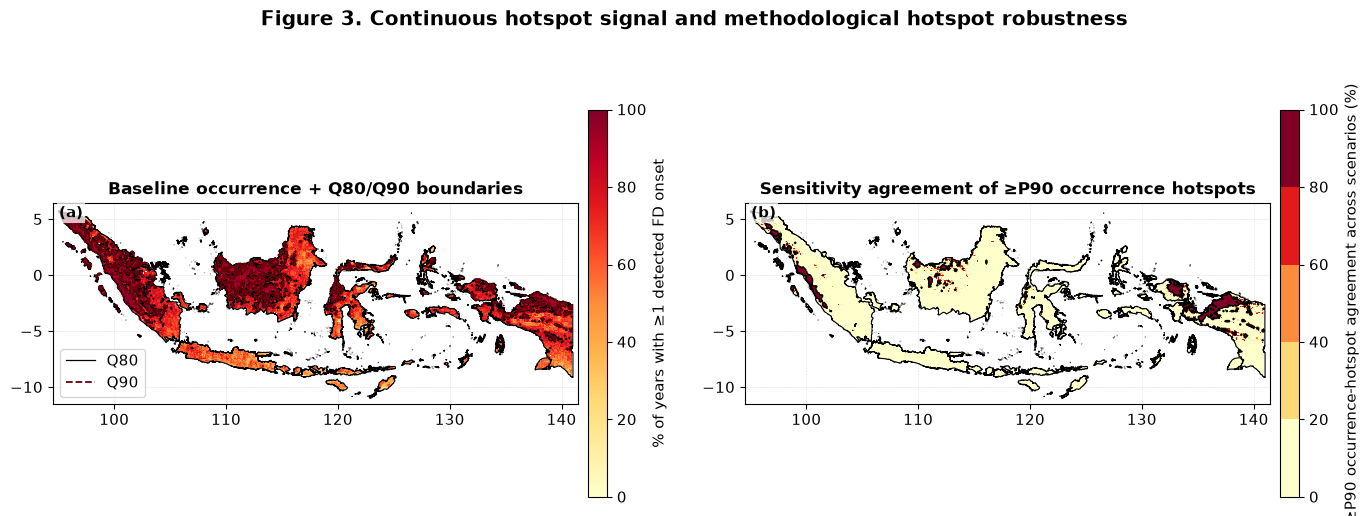

In [9]:
# ------------------------------------------------------------
# Compute ≥P90 occurrence-hotspot agreement across sensitivity scenarios.
# Only 2-D frequency fields are kept in memory.
# ------------------------------------------------------------
hotspot_masks = []
scenario_rows = []

for scenario, path in SCENARIO_FILES.items():
    ds_s = xr.open_dataset(
        path,
        chunks={"time_index": 73},
        mask_and_scale=False,
    )

    y_s = np.asarray(ds_s["year"].values, dtype=int)
    idx_s = np.flatnonzero(
        (y_s >= ANALYSIS_START)
        & (y_s <= ANALYSIS_END)
    )

    start_count = (
        (ds_s["fd_event_start"].isel(time_index=idx_s) == 1)
        .sum("time_index")
        .compute()
        .where(valid)
    )

    values = start_count.values[valid.values]
    q90_count = float(np.nanquantile(values, 0.90))

    mask_s = (
        (start_count >= q90_count)
        .where(valid, False)
        .astype(np.int8)
    )

    hotspot_masks.append(
        mask_s.expand_dims(scenario=[scenario])
    )

    scenario_rows.append({
        "scenario": scenario,
        "q90_event_count_threshold_1996_2024": q90_count,
    })

    ds_s.close()

hotspot_stack = xr.concat(
    hotspot_masks,
    dim="scenario",
)

q90_agreement = (
    hotspot_stack.mean("scenario") * 100.0
).where(valid)

pd.DataFrame(scenario_rows).to_csv(
    OUTPUT_DIR / "Table_Q90_threshold_by_scenario.csv",
    index=False,
)

q90_agreement.to_netcdf(
    OUTPUT_DIR / "q90_hotspot_sensitivity_agreement.nc"
)

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, 5.4))

# (a) baseline occurrence
ax1 = setup_map_ax(fig, 121)
im1 = map_mesh(
    ax1,
    clim["occurrence_probability_percent"],
    cmap=CMAP_WARM,
)
overlay_indonesia_boundary(ax1)

map_contour(
    ax1,
    hot["hotspot_q80"],
    level=0.5,
    color="black",
    linewidth=0.9,
)
map_contour(
    ax1,
    hot["hotspot_q90"],
    level=0.5,
    color="#67000d",
    linewidth=1.3,
    linestyle="--",
)

cb1 = fig.colorbar(im1, ax=ax1, pad=0.015, shrink=0.88)
cb1.set_label("% of years with ≥1 detected FD onset")
ax1.set_title("Baseline occurrence + Q80/Q90 boundaries")
panel_label(ax1, "(a)")

ax1.legend(
    handles=[
        Line2D([0], [0], color="black", lw=0.9, label="Q80"),
        Line2D([0], [0], color="#67000d", lw=1.3, ls="--", label="Q90"),
    ],
    loc="lower left",
    frameon=True,
)

# (b) cross-scenario agreement
ax2 = setup_map_ax(fig, 122)

bounds = np.arange(0, 101, 20)
agreement_cmap = mpl.colormaps["YlOrRd"].resampled(len(bounds) - 1)
agreement_norm = BoundaryNorm(bounds, agreement_cmap.N)

im2 = map_mesh(
    ax2,
    q90_agreement,
    cmap=agreement_cmap,
    norm=agreement_norm,
)
overlay_indonesia_boundary(ax2)

# stringent sensitivity agreement contour
robust80 = (q90_agreement >= 80).where(valid, False)
if bool(robust80.any().item()):
    map_contour(
        ax2,
        robust80.astype(np.int8),
        level=0.5,
        color="black",
        linewidth=1.1,
    )

cb2 = fig.colorbar(
    im2,
    ax=ax2,
    pad=0.015,
    shrink=0.88,
    boundaries=bounds,
    ticks=bounds,
)
cb2.set_label("≥P90 occurrence-hotspot agreement across scenarios (%)")
ax2.set_title("Sensitivity agreement of ≥P90 occurrence hotspots")
panel_label(ax2, "(b)")

fig.suptitle(
    "Figure 3. Continuous hotspot signal and methodological hotspot robustness",
    fontsize=14.5,
    fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.94])
safe_savefig(fig, "Figure3_hotspot_robustness.png")
plt.show()


# Figure 4 — Meteorological evolution around detected rapid-drying initiation

`lag 0` is the M2A rapid-drying initiation/baseline.

The shaded lag −3 to −1 interval is the **antecedent window**.
The observed national mean in that window is not a dry/hot precondition, so the figure deliberately does not label it as such.

The 95% intervals are obtained from **year-block bootstrap**, not from treating adjacent grid cells as independent samples.


Saved: D:\ERA5_LAND\output_fd_05_final_results\Figure4_event_aligned_drivers.png


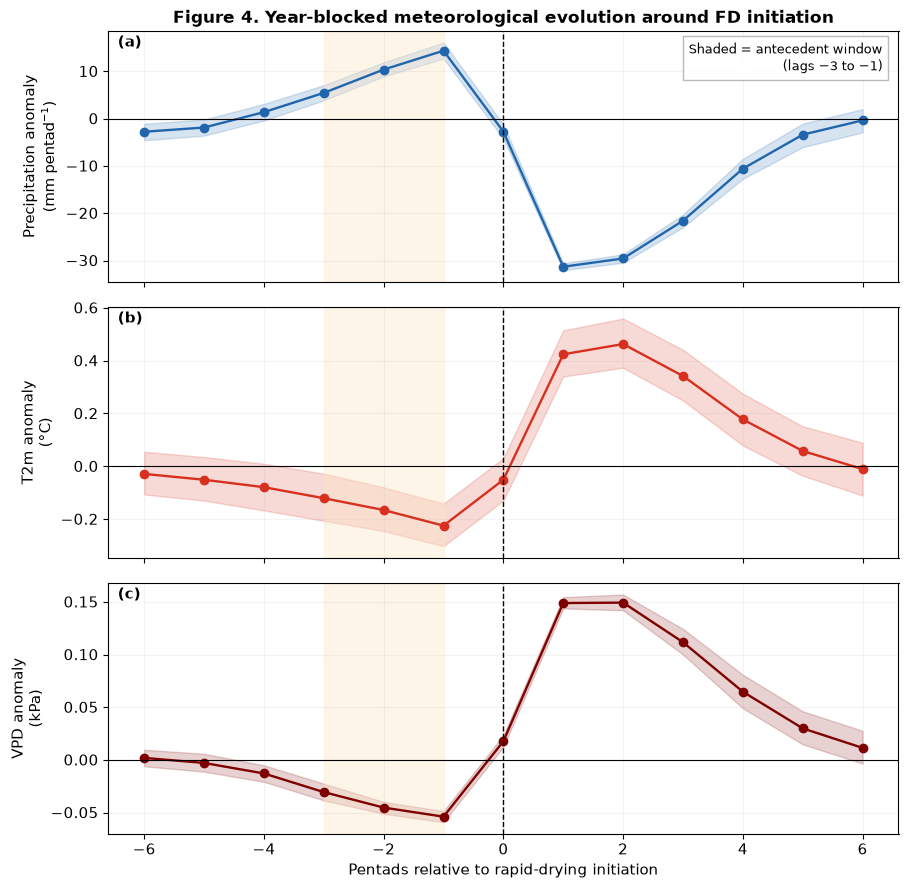

In [10]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(9.2, 9.0),
    sharex=True,
)

specs = [
    ("tp_anom_mm", "Precipitation anomaly\n(mm pentad$^{-1}$)", "#2166ac"),
    ("t2m_anom_c", "T2m anomaly\n(°C)", "#d7301f"),
    ("vpd_anom_kpa", "VPD anomaly\n(kPa)", "#7f0000"),
]

for i, (ax, (var, ylabel, color)) in enumerate(zip(axes, specs)):
    sub = lag.loc[lag["variable"] == var].sort_values("lag")

    ax.plot(
        sub["lag"],
        sub["mean"],
        marker="o",
        color=color,
        linewidth=1.7,
    )

    ax.fill_between(
        sub["lag"],
        sub["ci95_low"],
        sub["ci95_high"],
        color=color,
        alpha=0.18,
    )

    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linestyle="--", linewidth=1.0)
    ax.axvspan(-3, -1, color="#fee8c8", alpha=0.40)

    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.15)
    panel_label(ax, f"({chr(97+i)})")

axes[-1].set_xlabel("Pentads relative to rapid-drying initiation")
axes[0].set_title(
    "Figure 4. Year-blocked meteorological evolution around FD initiation"
)

axes[0].text(
    0.98,
    0.96,
    "Shaded = antecedent window\n(lags −3 to −1)",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    fontsize=9.5,
    bbox=dict(facecolor="white", edgecolor="0.7", alpha=0.9),
)

fig.tight_layout()
safe_savefig(fig, "Figure4_event_aligned_drivers.png")
plt.show()


# Figure 5 — Driver fingerprint during rapid development

This figure answers two different questions:

- **panel (a):** how far the mean meteorological state shifts from its pentad climatology;
- **panel (b):** how often strong diagnostic thresholds occur in FD rapid-development area–time samples.

VPD is used as an atmospheric-aridity / drying-demand proxy.
It is **not** treated as PET or actual ET.


Saved: D:\ERA5_LAND\output_fd_05_final_results\Figure5_driver_fingerprint.png


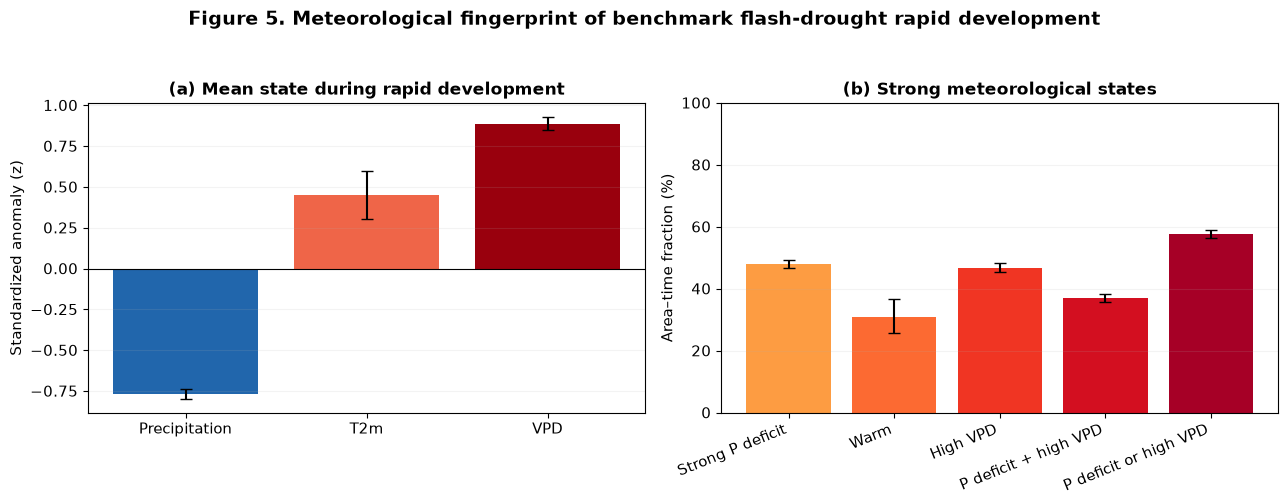

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.1))

# -------------------------------------------------
# (a) standardized means
# -------------------------------------------------
mean_keys = [
    ("mean_z_precip", "Precipitation", "#2166ac"),
    ("mean_z_t2m", "T2m", "#ef6548"),
    ("mean_z_vpd", "VPD", "#99000d"),
]

labels_a = []
means_a = []
loerr_a = []
hierr_a = []
colors_a = []

for key, label, color in mean_keys:
    m, lo, hi = phase_metric(key)
    labels_a.append(label)
    means_a.append(m)
    loerr_a.append(m - lo)
    hierr_a.append(hi - m)
    colors_a.append(color)

x = np.arange(len(labels_a))

axes[0].bar(
    x,
    means_a,
    color=colors_a,
    yerr=np.vstack([loerr_a, hierr_a]),
    capsize=4,
)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_a)
axes[0].set_ylabel("Standardized anomaly (z)")
axes[0].set_title("(a) Mean state during rapid development")
axes[0].grid(axis="y", alpha=0.15)

# -------------------------------------------------
# (b) strong-state fractions
# -------------------------------------------------
frac_keys = [
    ("strong_precip_deficit_fraction", "Strong P deficit"),
    ("warm_fraction", "Warm"),
    ("high_vpd_fraction", "High VPD"),
    ("compound_pdef_highvpd_fraction", "P deficit + high VPD"),
    ("either_pdef_or_highvpd_fraction", "P deficit or high VPD"),
]

labels_b = []
means_b = []
loerr_b = []
hierr_b = []

for key, label in frac_keys:
    m, lo, hi = phase_metric(key)
    labels_b.append(label)
    means_b.append(m * 100)
    loerr_b.append((m - lo) * 100)
    hierr_b.append((hi - m) * 100)

x2 = np.arange(len(labels_b))

axes[1].bar(
    x2,
    means_b,
    color=mpl.colormaps["YlOrRd"](
        np.linspace(0.45, 0.92, len(labels_b))
    ),
    yerr=np.vstack([loerr_b, hierr_b]),
    capsize=4,
)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(labels_b, rotation=22, ha="right")
axes[1].set_ylabel("Area–time fraction (%)")
axes[1].set_ylim(0, 100)
axes[1].set_title("(b) Strong meteorological states")
axes[1].grid(axis="y", alpha=0.15)

fig.suptitle(
    "Figure 5. Meteorological fingerprint of benchmark flash-drought rapid development",
    fontsize=14,
    fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.94])
safe_savefig(fig, "Figure5_driver_fingerprint.png")
plt.show()


# Figure 6 — Definition and percentile-method robustness

The final robustness conclusion should not be reduced to a single “valid / invalid” label.

The uploaded runs show:

- **4 vs 5 pentad onset:** nearly identical;
- **persistence:** absolute frequency and exact ≥P90 occurrence hotspot footprint are more sensitive;
- **percentile construction:** exact event identity changes, but the continuous spatial frequency pattern remains very highly correlated.

This distinction is important:
**continuous spatial structure can be robust even when individual grid-cell event identities or binary upper-tail hotspots are less stable.**


,variant,event_count,event_start_jaccard,frequency_spearman_r,q90_hotspot_jaccard,event_count_change_percent
0,Onset ≤4,558355,0.997640,0.999739,0.995655,-0.236029
1,Persistence 2,732894,0.763652,0.970673,0.612171,30.949692
2,Persistence 4,356010,0.636100,0.898351,0.401615,-36.389983
3,Percentile WIN1,601708,0.676440,0.977550,0.664160,7.510059
4,Percentile WIN2,580598,0.615906,0.973109,0.632075,3.738234
5,Rate ≥7.5,552448,0.987085,0.998509,0.973309,-1.291461
6,Rate ≥10,539826,0.964533,0.995299,0.895009,-3.546695


Saved: D:\ERA5_LAND\output_fd_05_final_results\Figure6_methodological_robustness.png


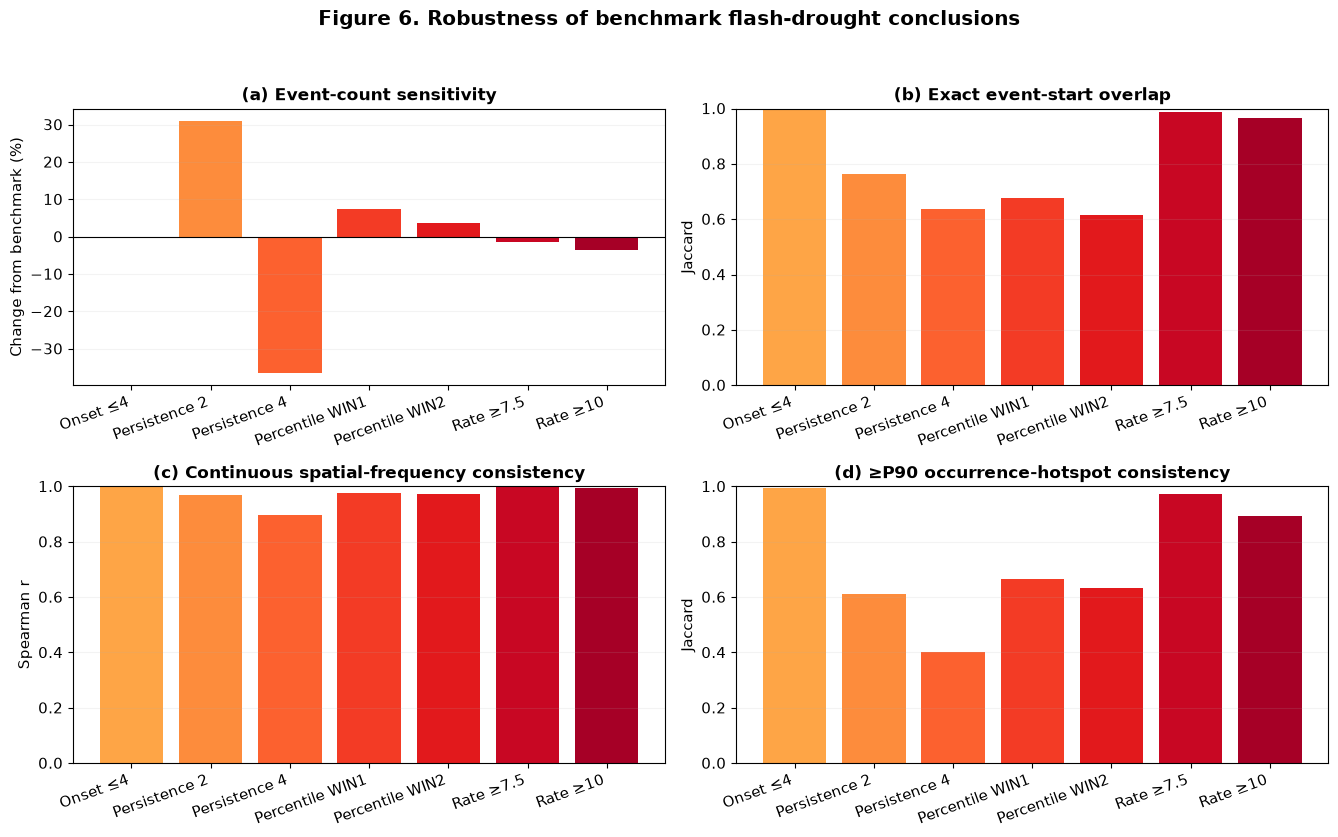

In [12]:
# ============================================================
# Build one comparable sensitivity table
# ============================================================
baseline_count = int(
    onset_summary.loc[
        onset_summary["method"] == "ONSET5_PERSIST3_BASELINE",
        "gridcell_event_starts_1996_2024",
    ].iloc[0]
)

sensitivity_rows = []

# Onset4
r = onset_summary.loc[
    onset_summary["method"] == "ONSET4_PERSIST3"
].iloc[0]
c = onset_consist.iloc[0]
sensitivity_rows.append({
    "variant": "Onset ≤4",
    "event_count": int(r["gridcell_event_starts_1996_2024"]),
    "event_start_jaccard": float(c["event_start_jaccard"]),
    "frequency_spearman_r": float(c["frequency_spearman_r"]),
    "q90_hotspot_jaccard": float(c["q90_hotspot_jaccard"]),
})

# Persistence
for label in ["P2", "P4"]:
    r = persist_summary.loc[persist_summary["method"] == label].iloc[0]
    c = persist_consist.loc[persist_consist["variant"] == label].iloc[0]

    sensitivity_rows.append({
        "variant": f"Persistence {label[-1]}",
        "event_count": int(r["gridcell_event_starts_1996_2024"]),
        "event_start_jaccard": float(c["event_start_jaccard"]),
        "frequency_spearman_r": float(c["frequency_spearman_r"]),
        "q90_hotspot_jaccard": float(c["q90_hotspot_jaccard"]),
    })

# Percentile
for label in ["WIN1", "WIN2"]:
    r = pct_summary.loc[pct_summary["method"] == label].iloc[0]
    c = pct_consist.loc[pct_consist["variant"] == label].iloc[0]

    sensitivity_rows.append({
        "variant": f"Percentile {label}",
        "event_count": int(r["gridcell_event_starts_1996_2024"]),
        "event_start_jaccard": float(c["event_start_jaccard"]),
        "frequency_spearman_r": float(c["frequency_spearman_r"]),
        "q90_hotspot_jaccard": float(c["q90_hotspot_jaccard"]),
    })

# Decline rate
for method, label in [
    ("RATE7P5", "Rate ≥7.5"),
    ("RATE10", "Rate ≥10"),
]:
    r = rate_summary.loc[
        rate_summary["method"] == method
    ].iloc[0]

    c = rate_consist.loc[
        rate_consist["variant"] == method
    ].iloc[0]

    sensitivity_rows.append({
        "variant": label,
        "event_count": int(
            r["gridcell_event_starts_1996_2024"]
        ),
        "event_start_jaccard": float(
            c["event_start_jaccard"]
        ),
        "frequency_spearman_r": float(
            c["frequency_spearman_r"]
        ),
        "q90_hotspot_jaccard": float(
            c["q90_hotspot_jaccard"]
        ),
    })

sens = pd.DataFrame(sensitivity_rows)

sens["event_count_change_percent"] = (
    (sens["event_count"] - baseline_count)
    / baseline_count
    * 100.0
)

sens.to_csv(
    OUTPUT_DIR / "Table1_final_sensitivity_summary.csv",
    index=False,
)

display(sens)

# ============================================================
# Figure
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.5))

x = np.arange(len(sens))
colors = mpl.colormaps["YlOrRd"](np.linspace(0.42, 0.92, len(sens)))

axes[0, 0].bar(
    x,
    sens["event_count_change_percent"],
    color=colors,
)
axes[0, 0].axhline(0, color="black", linewidth=0.8)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(sens["variant"], rotation=20, ha="right")
axes[0, 0].set_ylabel("Change from benchmark (%)")
axes[0, 0].set_title("(a) Event-count sensitivity")
axes[0, 0].grid(axis="y", alpha=0.15)

axes[0, 1].bar(
    x,
    sens["event_start_jaccard"],
    color=colors,
)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(sens["variant"], rotation=20, ha="right")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_ylabel("Jaccard")
axes[0, 1].set_title("(b) Exact event-start overlap")
axes[0, 1].grid(axis="y", alpha=0.15)

axes[1, 0].bar(
    x,
    sens["frequency_spearman_r"],
    color=colors,
)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(sens["variant"], rotation=20, ha="right")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].set_ylabel("Spearman r")
axes[1, 0].set_title("(c) Continuous spatial-frequency consistency")
axes[1, 0].grid(axis="y", alpha=0.15)

axes[1, 1].bar(
    x,
    sens["q90_hotspot_jaccard"],
    color=colors,
)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(sens["variant"], rotation=20, ha="right")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_ylabel("Jaccard")
axes[1, 1].set_title("(d) ≥P90 occurrence-hotspot consistency")
axes[1, 1].grid(axis="y", alpha=0.15)

fig.suptitle(
    "Figure 6. Robustness of benchmark flash-drought conclusions",
    fontsize=14.5,
    fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.95])
safe_savefig(fig, "Figure6_methodological_robustness.png")
plt.show()


# Figure 7 — Representative event evolution for the four **final M2A top years**

This figure corrects an important issue in previous Notebook 5 versions:

- the top four years are **not hard-coded**;
- they are read directly from the final M2A annual ranking;
- the representative grid is **not the most severe grid in the country**.

Instead, for each top year the notebook:

1. takes the national pentad of maximum drought-core area;
2. identifies the largest spatially connected P20 drought-core cluster;
3. computes that cluster's area-weighted centroid;
4. selects a grid near the centroid whose detected event actually spans the national peak pentad.

This is closer to a **spatially representative core example** of the large episode than selecting the maximum-severity outlier.

The total detected episode may be much longer than the rapid onset; always interpret `onset_time` separately from `duration`.


Saved: D:\ERA5_LAND\output_fd_05_final_results\Figure7_top4_representative_core_events.png


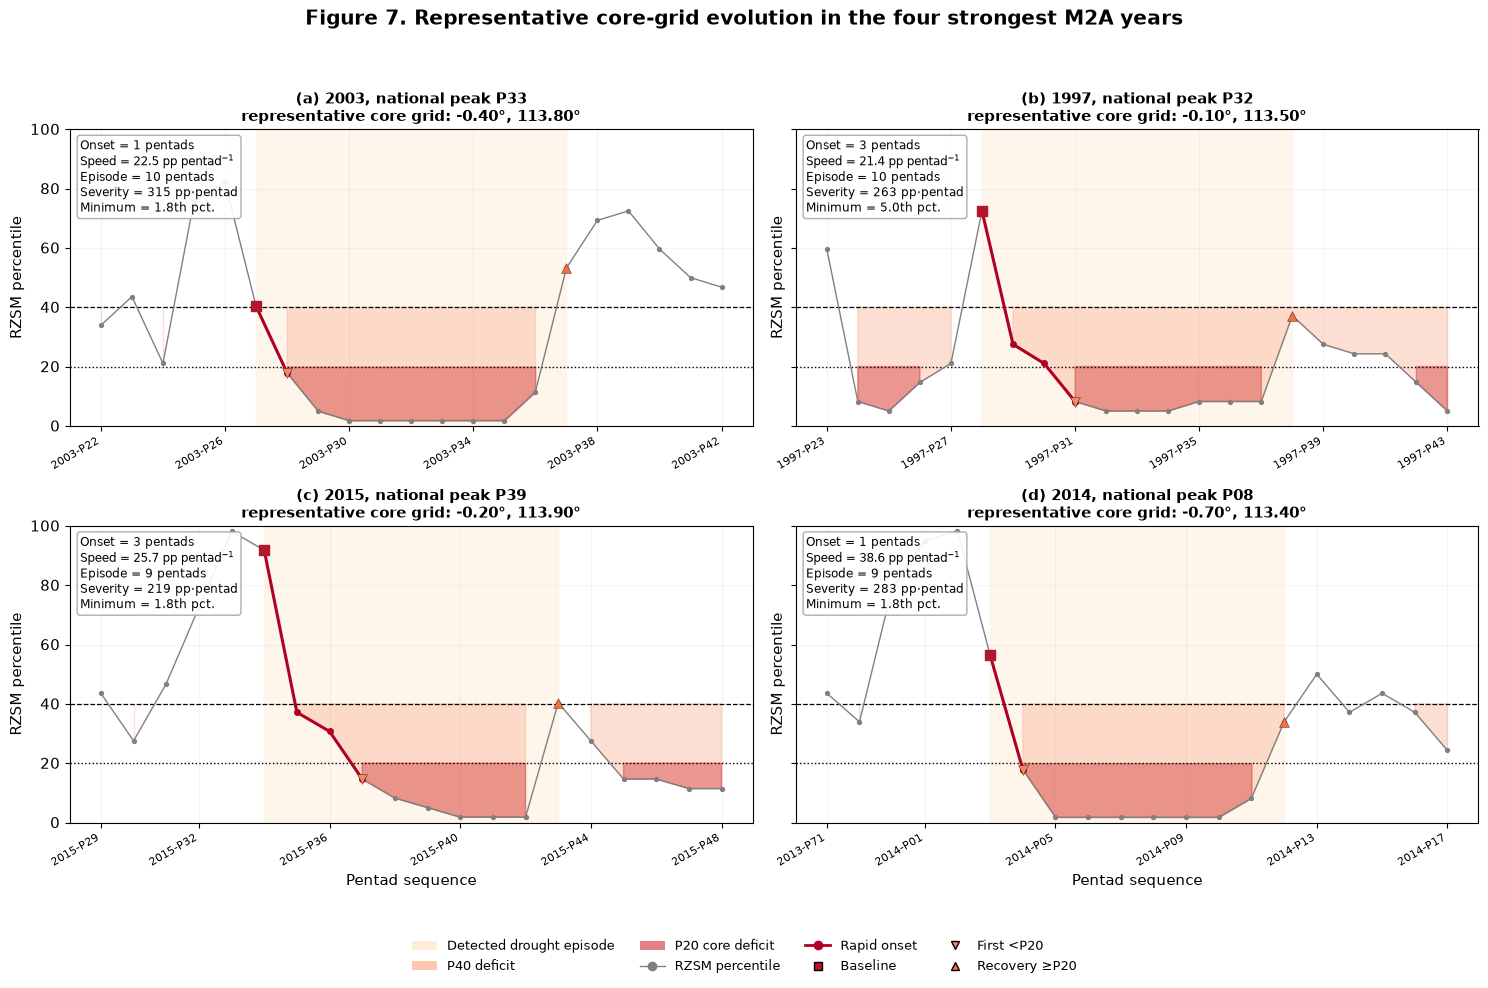

,year,national_peak_pentad,peak_time_index,start_time_index,latitude_index,longitude_index,latitude,longitude,cluster_centroid_lat,cluster_centroid_lon,cluster_grid_count,onset_time_pentads,onset_speed_pp_per_pentad,duration_pentads,severity_p40,minimum_percentile
0,2003,33,616,610,106,188,-0.4,113.8,-0.419612,113.822795,3984,1,22.493574,10,314.884308,1.799486
1,1997,32,177,173,109,185,-0.1,113.5,-0.128154,113.520850,3222,3,21.422453,10,263.470428,5.012854
2,2015,39,1498,1493,108,189,-0.2,113.9,-0.138855,113.884678,3747,3,25.706942,9,218.843185,1.799486
3,2014,8,1394,1389,103,184,-0.7,113.4,-0.694442,113.446858,3505,1,38.560410,9,283.110535,1.799486


In [13]:
# ============================================================
# Percentile data reshaped into detection time_index ordering
# ============================================================
pct_ds = xr.open_dataset(PERCENTILE_FILE)
pct4 = pct_ds["rzsm_percentile"].transpose(
    "year", "pentad", "latitude", "longitude"
)

pct_time = (
    pct4.stack(time_index=("year", "pentad"))
    .transpose("time_index", "latitude", "longitude")
    .reset_index("time_index", drop=True)
    .assign_coords(
        time_index=np.arange(
            pct4.sizes["year"] * pct4.sizes["pentad"]
        )
    )
)

if pct_time.sizes["time_index"] != det.sizes["time_index"]:
    raise ValueError("Percentile and detection time axes differ.")

lat = np.asarray(det["latitude"].values, dtype=float)
lon = np.asarray(det["longitude"].values, dtype=float)
coslat = np.cos(np.deg2rad(lat))

full_year = np.asarray(det["year"].values, dtype=int)
full_pentad = np.asarray(det["pentad"].values, dtype=int)

labels_full = [
    f"{yy}-P{pp:02d}"
    for yy, pp in zip(full_year, full_pentad)
]


def largest_core_cluster_at_peak(year, pentad):
    match = np.flatnonzero(
        (full_year == int(year))
        & (full_pentad == int(pentad))
    )

    if match.size != 1:
        raise ValueError(
            f"Expected one time index for {year} P{pentad}; "
            f"found {match.size}."
        )

    peak_t = int(match[0])

    core = (
        det["fd_drought_core"]
        .isel(time_index=peak_t)
        .values == 1
    )

    core = core & valid.values

    # 8-neighbour connectivity.
    structure = np.ones((3, 3), dtype=np.int8)
    labelled, nlab = ndimage.label(core, structure=structure)

    if nlab == 0:
        raise ValueError(
            f"No drought-core grid at {year} P{pentad}."
        )

    best_label = None
    best_weight = -np.inf

    for lab_id in range(1, nlab + 1):
        iy, ix = np.where(labelled == lab_id)
        if iy.size == 0:
            continue

        w = coslat[iy]
        total_w = float(np.sum(w))

        if total_w > best_weight:
            best_weight = total_w
            best_label = lab_id

    iy, ix = np.where(labelled == best_label)
    w = coslat[iy]

    centroid_lat = float(
        np.average(lat[iy], weights=w)
    )
    centroid_lon = float(
        np.average(lon[ix], weights=w)
    )

    # Nearest grids to the centroid.
    dist2 = (
        (lat[iy] - centroid_lat) ** 2
        + (
            (lon[ix] - centroid_lon)
            * np.cos(np.deg2rad(centroid_lat))
        ) ** 2
    )

    order = np.argsort(dist2)

    for k in order:
        gy = int(iy[k])
        gx = int(ix[k])

        start_series = (
            det["fd_event_start"]
            .isel(latitude=gy, longitude=gx)
            .values == 1
        )

        starts = np.flatnonzero(start_series)

        if starts.size == 0:
            continue

        durations = (
            det["duration_pentads_at_start"]
            .isel(latitude=gy, longitude=gx)
            .values
        )

        covering = [
            int(s)
            for s in starts
            if durations[s] > 0
            and int(s) <= peak_t < int(s + durations[s])
        ]

        if covering:
            # If more than one candidate, choose latest start before peak.
            start_t = max(covering)

            return {
                "peak_time_index": peak_t,
                "start_time_index": start_t,
                "latitude_index": gy,
                "longitude_index": gx,
                "latitude": float(lat[gy]),
                "longitude": float(lon[gx]),
                "cluster_centroid_lat": centroid_lat,
                "cluster_centroid_lon": centroid_lon,
                "cluster_grid_count": int(iy.size),
            }

    raise RuntimeError(
        f"No covering event found inside largest core cluster for {year} P{pentad}."
    )


def plot_representative_event(ax, year, peak_pentad, panel):
    rep = largest_core_cluster_at_peak(
        int(year),
        int(peak_pentad),
    )

    st = int(rep["start_time_index"])
    gy = int(rep["latitude_index"])
    gx = int(rep["longitude_index"])

    onset_time = int(
        det["onset_time_pentads_at_start"]
        .isel(
            time_index=st,
            latitude=gy,
            longitude=gx,
        )
        .values
    )

    duration = int(
        det["duration_pentads_at_start"]
        .isel(
            time_index=st,
            latitude=gy,
            longitude=gx,
        )
        .values
    )

    onset_speed = float(
        det["onset_speed_at_start"]
        .isel(
            time_index=st,
            latitude=gy,
            longitude=gx,
        )
        .values
    )

    severity = float(
        det["severity_p40_at_start"]
        .isel(
            time_index=st,
            latitude=gy,
            longitude=gx,
        )
        .values
    )

    minimum = float(
        det["minimum_percentile_at_start"]
        .isel(
            time_index=st,
            latitude=gy,
            longitude=gx,
        )
        .values
    )

    crossing = st + onset_time
    termination = st + duration

    left = max(0, st - 5)
    right = min(
        det.sizes["time_index"],
        termination + 6,
    )

    x = np.arange(left, right)
    y = (
        pct_time
        .isel(
            time_index=slice(left, right),
            latitude=gy,
            longitude=gx,
        )
        .values
    )

    # Full trajectory
    ax.plot(
        x,
        y,
        color="0.5",
        marker="o",
        markersize=2.8,
        linewidth=1.0,
        zorder=4,
    )

    # Episode shading and percentile-deficit fills
    ax.axvspan(
        st,
        termination,
        color="#fee8c8",
        alpha=0.36,
        zorder=0,
    )

    ax.fill_between(
        x,
        40,
        y,
        where=y < 40,
        color="#fcae91",
        alpha=0.40,
        zorder=1,
    )

    ax.fill_between(
        x,
        20,
        y,
        where=y < 20,
        color="#cb181d",
        alpha=0.36,
        zorder=2,
    )

    # Onset stage
    xx = np.arange(st, crossing + 1)
    yy = (
        pct_time
        .isel(
            time_index=slice(st, crossing + 1),
            latitude=gy,
            longitude=gx,
        )
        .values
    )

    ax.plot(
        xx,
        yy,
        color="#b10026",
        marker="o",
        markersize=4,
        linewidth=2.2,
        zorder=6,
    )

    # Thresholds
    ax.axhline(40, color="black", linestyle="--", linewidth=0.9)
    ax.axhline(20, color="black", linestyle=":", linewidth=1.0)

    ax.scatter(
        [st],
        [float(pct_time.isel(time_index=st, latitude=gy, longitude=gx).values)],
        marker="s",
        color="#b2182b",
        s=42,
        zorder=8,
    )

    ax.scatter(
        [crossing],
        [float(pct_time.isel(time_index=crossing, latitude=gy, longitude=gx).values)],
        marker="v",
        color="#ef8a62",
        edgecolor="black",
        linewidth=0.25,
        s=50,
        zorder=8,
    )

    ax.scatter(
        [termination],
        [float(pct_time.isel(time_index=termination, latitude=gy, longitude=gx).values)],
        marker="^",
        color="#f46d43",
        edgecolor="black",
        linewidth=0.25,
        s=50,
        zorder=8,
    )

    ax.set_ylim(0, 100)
    ax.set_ylabel("RZSM percentile")
    ax.grid(alpha=0.13)

    ntick = min(6, len(x))
    tind = np.linspace(0, len(x)-1, ntick, dtype=int)
    ax.set_xticks(x[tind])
    ax.set_xticklabels(
        [labels_full[left + i] for i in tind],
        rotation=30,
        ha="right",
        fontsize=8,
    )

    ax.set_title(
        f"({panel}) {int(year)}, national peak P{int(peak_pentad):02d}\n"
        f"representative core grid: {rep['latitude']:.2f}°, {rep['longitude']:.2f}°",
        fontsize=10.5,
    )

    info = (
        f"Onset = {onset_time} pentads\n"
        f"Speed = {onset_speed:.1f} pp pentad$^{{-1}}$\n"
        f"Episode = {duration} pentads\n"
        f"Severity = {severity:.0f} pp·pentad\n"
        f"Minimum = {minimum:.1f}th pct."
    )

    ax.text(
        0.015,
        0.97,
        info,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.3,
        bbox=dict(
            facecolor="white",
            edgecolor="0.65",
            alpha=0.9,
            boxstyle="round,pad=0.25",
        ),
        zorder=20,
    )

    return {
        "year": int(year),
        "national_peak_pentad": int(peak_pentad),
        **rep,
        "onset_time_pentads": onset_time,
        "onset_speed_pp_per_pentad": onset_speed,
        "duration_pentads": duration,
        "severity_p40": severity,
        "minimum_percentile": minimum,
    }


fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10),
    sharey=True,
)

case_rows = []

for ax, row, letter in zip(
    axes.ravel(),
    top_years.itertuples(index=False),
    ["a", "b", "c", "d"],
):
    case_rows.append(
        plot_representative_event(
            ax,
            int(row.year),
            int(row.pentad_of_maximum_core_area),
            letter,
        )
    )

axes[1, 0].set_xlabel("Pentad sequence")
axes[1, 1].set_xlabel("Pentad sequence")

legend_handles = [
    Patch(facecolor="#fee8c8", edgecolor="none", alpha=0.7, label="Detected drought episode"),
    Patch(facecolor="#fcae91", edgecolor="none", alpha=0.7, label="P40 deficit"),
    Patch(facecolor="#cb181d", edgecolor="none", alpha=0.55, label="P20 core deficit"),
    Line2D([0], [0], color="0.5", marker="o", lw=1, label="RZSM percentile"),
    Line2D([0], [0], color="#b10026", marker="o", lw=2, label="Rapid onset"),
    Line2D([0], [0], marker="s", color="none", markerfacecolor="#b2182b", label="Baseline"),
    Line2D([0], [0], marker="v", color="none", markerfacecolor="#ef8a62", label="First <P20"),
    Line2D([0], [0], marker="^", color="none", markerfacecolor="#f46d43", label="Recovery ≥P20"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.005),
    ncol=4,
    frameon=False,
    fontsize=9,
)

fig.suptitle(
    "Figure 7. Representative core-grid evolution in the four strongest M2A years",
    fontsize=14.5,
    fontweight="bold",
)

fig.tight_layout(rect=[0, 0.085, 1, 0.95])
safe_savefig(fig, "Figure7_top4_representative_core_events.png")
plt.show()

case_metadata = pd.DataFrame(case_rows)
case_metadata.to_csv(
    OUTPUT_DIR / "Table2_top4_representative_core_events.csv",
    index=False,
)
display(case_metadata)

pct_ds.close()


# Supplementary Figure S1 — Binary baseline Q80/≥P90 occurrence masks

Keep this supplementary.

A white grid means **below the chosen national upper-tail cutoff**, not “no flash drought”.
The scientifically preferred hotspot figure is Figure 3, which shows the continuous occurrence field and multi-scenario agreement.


Saved: D:\ERA5_LAND\output_fd_05_final_results\FigureS1_binary_hotspot_masks.png


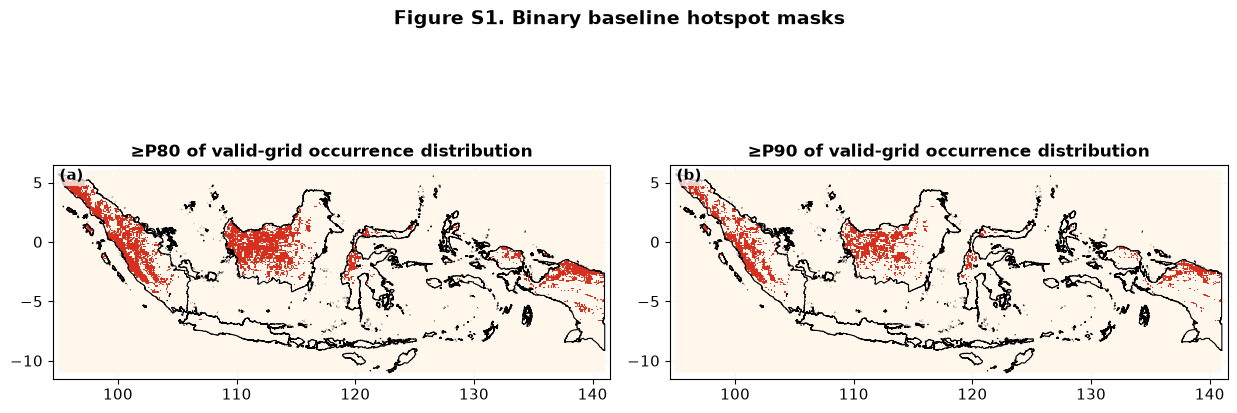

In [14]:
fig = plt.figure(figsize=(12.5, 4.8))

binary_cmap = ListedColormap(["#fff7ec", "#d7301f"])
binary_norm = BoundaryNorm([-0.5, 0.5, 1.5], binary_cmap.N)

for pos, var, title, letter in [
    (121, "hotspot_q80", "≥P80 of valid-grid occurrence distribution", "a"),
    (122, "hotspot_q90", "≥P90 of valid-grid occurrence distribution", "b"),
]:
    ax = setup_map_ax(fig, pos)

    im = map_mesh(
        ax,
        hot[var],
        cmap=binary_cmap,
        norm=binary_norm,
    )

    overlay_indonesia_boundary(ax)
    ax.set_title(title)
    panel_label(ax, f"({letter})")

fig.suptitle(
    "Figure S1. Binary baseline hotspot masks",
    fontsize=14,
    fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.94])
safe_savefig(fig, "FigureS1_binary_hotspot_masks.png")
plt.show()


# Supplementary Figure S2 — Spatial timing of the strongest national year

This case-style map follows the visual logic of event-evolution figures in the flash-drought literature.

For the strongest final M2A year, it maps the **first detected FD initiation pentad** at each grid.

It does not imply that all coloured grid cells belong to one single meteorological system.


Saved: D:\ERA5_LAND\output_fd_05_final_results\FigureS2_first_initiation_2003.png


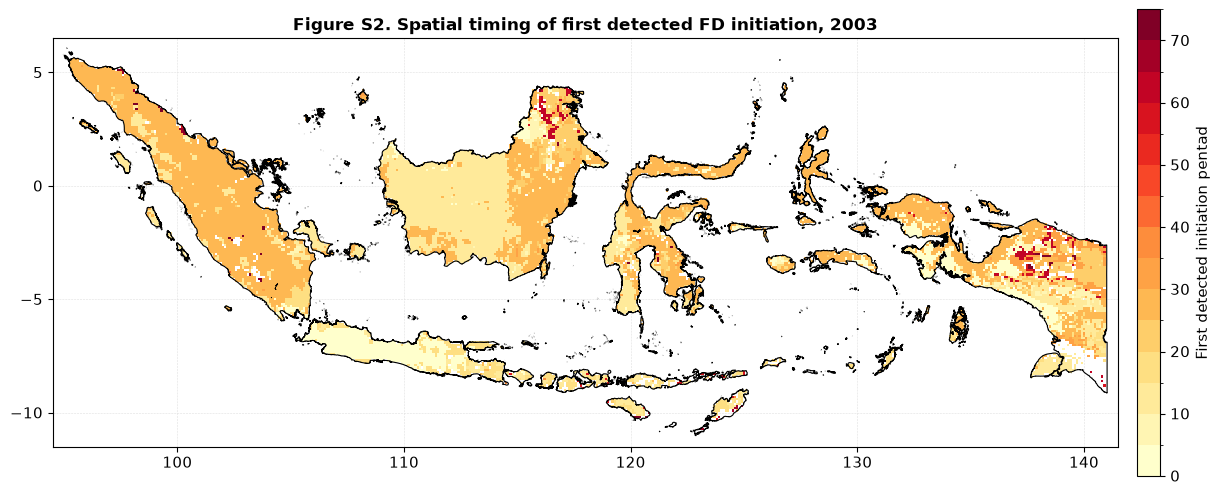

In [15]:
case_year = int(top_years.iloc[0]["year"])

case_idx = np.flatnonzero(
    np.asarray(det["year"].values, dtype=int) == case_year
)

case = det.isel(time_index=case_idx)

start_case = (
    case["fd_event_start"] == 1
)

first_onset = (
    case["pentad"]
    .where(start_case)
    .min("time_index")
    .where(valid)
    .compute()
)

vals = first_onset.values[np.isfinite(first_onset.values)]

if vals.size == 0:
    raise ValueError(
        f"No FD onset found in strongest year {case_year}."
    )

pmin = int(np.nanmin(vals))
pmax = int(np.nanmax(vals))

# Use 5-pentad bins if the year spans many initiation pentads.
step = 5
lo = (pmin // step) * step
hi = ((pmax // step) + 1) * step
bounds = np.arange(lo, hi + step, step)

if bounds.size < 3:
    bounds = np.arange(pmin, pmax + 2)

cmap_onset = mpl.colormaps["YlOrRd"].resampled(
    max(2, len(bounds) - 1)
)
norm_onset = BoundaryNorm(bounds, cmap_onset.N)

fig = plt.figure(figsize=(13.5, 5.5))
ax = setup_map_ax(fig, 111)

im = map_mesh(
    ax,
    first_onset,
    cmap=cmap_onset,
    norm=norm_onset,
)

overlay_indonesia_boundary(ax)

cb = fig.colorbar(
    im,
    ax=ax,
    pad=0.015,
    shrink=0.90,
    boundaries=bounds,
)
cb.set_label("First detected initiation pentad")

ax.set_title(
    f"Figure S2. Spatial timing of first detected FD initiation, {case_year}"
)

fig.tight_layout()
safe_savefig(
    fig,
    f"FigureS2_first_initiation_{case_year}.png",
)
plt.show()


# 8. Final interpretation block for thesis writing

The statements printed below are intentionally conservative.

They distinguish:
- robust findings;
- definition-sensitive findings;
- unsupported causal claims.


In [16]:
# Core event characteristics
mean_onset = event_stat("onset_time_pentads_at_start")
mean_speed = event_stat("onset_speed_at_start")
mean_duration = event_stat("duration_pentads_at_start")
mean_persist = event_stat("below_p20_pentads_at_start")

# Sensitivity ranges
min_freq_r = float(sens["frequency_spearman_r"].min())
min_q90_j = float(sens["q90_hotspot_jaccard"].min())

print("FINAL INTERPRETATION")
print("====================")
print()
print(
    f"1) Benchmark M2A detects {benchmark_event_count:,} grid-cell starts "
    f"during {ANALYSIS_START}–{ANALYSIS_END} over {n_valid:,} valid Indonesian grids."
)
print(
    f"2) Rapid development is short: mean onset time = {mean_onset:.2f} pentads, "
    f"with mean onset speed = {mean_speed:.2f} percentile points pentad-1."
)
print(
    f"3) The detected drought episode persists much longer than the rapid onset: "
    f"mean episode duration = {mean_duration:.2f} pentads and initial P20 persistence "
    f"= {mean_persist:.2f} pentads."
)
print(
    f"4) The four largest benchmark years by simultaneous drought-core area are "
    f"{', '.join(str(int(y)) for y in top_years['year'])}."
)
print(
    f"5) No statistically significant monotonic trend was detected in the three "
    "national annual FD-area metrics during this record (all p≥0.05). "
    "This should not be shortened to a claim of no trend."
)
print(
    f"6) Onset-window and decline-rate sensitivity are small. "
    f"RATE7.5 and RATE10 preserve very high spatial-frequency agreement "
    f"(r={rate7['frequency_spearman_r']:.3f} and "
    f"{rate10['frequency_spearman_r']:.3f}), while persistence and "
    f"percentile construction alter exact event identities and "
    f"≥P90 occurrence masks more strongly."
)
print(
    f"   Even so, the minimum spatial frequency Spearman correlation across the tested "
    f"variants is {min_freq_r:.3f}, showing that the broad continuous spatial pattern "
    "is much more stable than the exact upper-tail hotspot boundary."
)
print(
    f"   Decline-rate sensitivity: RATE7.5 changes event count by "
    f"{float(rate_summary.loc[rate_summary['method']=='RATE7P5', 'event_count_change_percent_vs_RATE5'].iloc[0]):+.2f}% "
    f"and RATE10 by "
    f"{float(rate_summary.loc[rate_summary['method']=='RATE10', 'event_count_change_percent_vs_RATE5'].iloc[0]):+.2f}% "
    f"relative to RATE5."
)
print(
    f"7) During rapid development, mean standardized anomalies are "
    f"P={zp[0]:+.3f}, T2m={zt[0]:+.3f}, VPD={zv[0]:+.3f}."
)
print(
    f"   Strong P deficit occurs in {fp[0]*100:.1f}% of rapid-development area-ti   me samples, "
    f"high VPD in {fv[0]*100:.1f}%, and compound P-deficit + high-VPD in "
    f"{fc[0]*100:.1f}%."
)
print()
print("SUPPORTED LANGUAGE:")
print(
    "Indonesian flash drought is characterized by rapid RZSM depletion associated "
    "with an abrupt shift toward precipitation deficit and elevated atmospheric aridity."
)
print()
print("DO NOT CLAIM YET:")
print("- the exact P80/P90 occurrence-mask footprint is physically fixed or definition-independent;")
print("- ENSO/IOD causes the detected events (not analysed here);")
print("- VPD is the same as ET or PET;")
print("- causal attribution from the composite alone;")
print("- independent validation, because SMAP is not used.")


FINAL INTERPRETATION

1) Benchmark M2A detects 559,676 grid-cell starts during 1996–2024 over 14,857 valid Indonesian grids.
2) Rapid development is short: mean onset time = 1.72 pentads, with mean onset speed = 32.96 percentile points pentad-1.
3) The detected drought episode persists much longer than the rapid onset: mean episode duration = 7.65 pentads and initial P20 persistence = 5.93 pentads.
4) The four largest benchmark years by simultaneous drought-core area are 2003, 1997, 2015, 2014.
5) No statistically significant monotonic trend was detected in the three national annual FD-area metrics during this record (all p≥0.05). This should not be shortened to a claim of no trend.
6) Onset-window and decline-rate sensitivity are small. RATE7.5 and RATE10 preserve very high spatial-frequency agreement (r=0.999 and 0.995), while persistence and percentile construction alter exact event identities and ≥P90 occurrence masks more strongly.
   Even so, the minimum spatial frequency Spearma

## SMAP status

SMAP is **not required** for this Notebook 5.

If added later, it should be presented as an **independent cross-dataset consistency supplement**, not as something needed to rescue the ERA5-Land analysis.

For the current thesis scope, the completed onset, persistence, and percentile-construction tests already provide the required methodological robustness assessment.


## Final methodological status

**Final benchmark:** M2A, described as an adapted literature-informed
soil-moisture-percentile flash-drought benchmark.

**Analysis period:** 1996–2024.

**Robustness dimensions completed:**
onset window, P20 persistence, percentile construction, and minimum decline rate.

**Driver inference:** year-block P/T/VPD association analysis with exact temporal
alignment QC; not causal attribution.

**Validation language:** no independent validation is claimed because SMAP is not
used. The appropriate terms are detection, sensitivity, consistency, and robustness.

**Freeze rule:** do not change thresholds, benchmark definition, top-year selection,
or figure logic after this point merely to obtain a preferred spatial pattern.


In [17]:
manifest = {
    "notebook": "05_FINAL_RESULTS_SYNTHESIS_INDONESIA_FROZEN",
    "primary_benchmark": "M2A -> FD_BENCHMARK",
    "benchmark_definition_role": "adapted literature-informed soil-moisture-percentile benchmark",
    "exact_replication_of_single_published_definition": False,
    "analysis_period": [ANALYSIS_START, ANALYSIS_END],
    "independent_validation_claimed": False,
    "workflow_frozen": True,
    "frozen_scope": "current thesis core analysis",
    "qc_2003_verified_from_executed_notebook": True,
    "driver_year_pentad_alignment_verified_from_executed_notebook": True,
    "independent_internal_sanity_check_2003_required": True,
    "independent_internal_sanity_check_2003_passed": bool(qc_2003["overall_pass"].iloc[0]),
    "smap_required": False,
    "decline_rate_sensitivity_integrated": True,
    "main_source_products": {
        "climatology": str(CLIM_DIR),
        "drivers": str(DRIVER_DIR),
        "onset_sensitivity": str(ONSET_DIR),
        "percentile_sensitivity": str(PCT_DIR),
        "decline_rate_sensitivity": str(RATE_DIR),
        "detection": str(DETECTION_FILE),
    },
    "excluded_from_primary_synthesis": {
        "03c": "PRIMARY_METHOD=M1; requires M2A rebuild before primary regional inference",
        "old_04": "M1 all-event grid-cell composite; superseded by year-block M2A 04b",
        "old_02_03_bbox": "screening / pre-final Indonesia mask products",
    },
    "main_figures": [
        "Figure1_benchmark_climatology.png",
        "Figure2_temporal_characteristics.png",
        "Figure3_hotspot_robustness.png",
        "Figure4_event_aligned_drivers.png",
        "Figure5_driver_fingerprint.png",
        "Figure6_methodological_robustness.png",
        "Figure7_top4_representative_core_events.png",
    ],
    "supplementary_figures": [
        "FigureS1_binary_hotspot_masks.png",
        f"FigureS2_first_initiation_{int(top_years.iloc[0]['year'])}.png",
    ],
    "hotspot_terminology": "P80/P90 = >= percentile threshold of valid-grid occurrence distribution; not exact land-area fractions",
    "trend_terminology": "no statistically significant monotonic trend detected when p>=0.05",
    "interpretation": (
        "Detection + methodological sensitivity/consistency/robustness; "
        "physical-driver association, not causal attribution."
    ),
}

(OUTPUT_DIR / "manifest_05_final_results.json").write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8",
)

# Close open products
clim.close()
hot.close()
det.close()

print("Notebook 05 final synthesis complete.")
print("Output directory:", OUTPUT_DIR)


Notebook 05 final synthesis complete.
Output directory: D:\ERA5_LAND\output_fd_05_final_results


Saved: D:\ERA5_LAND\output_fd_05_final_results\Figure1_benchmark_climatology_3x2.png


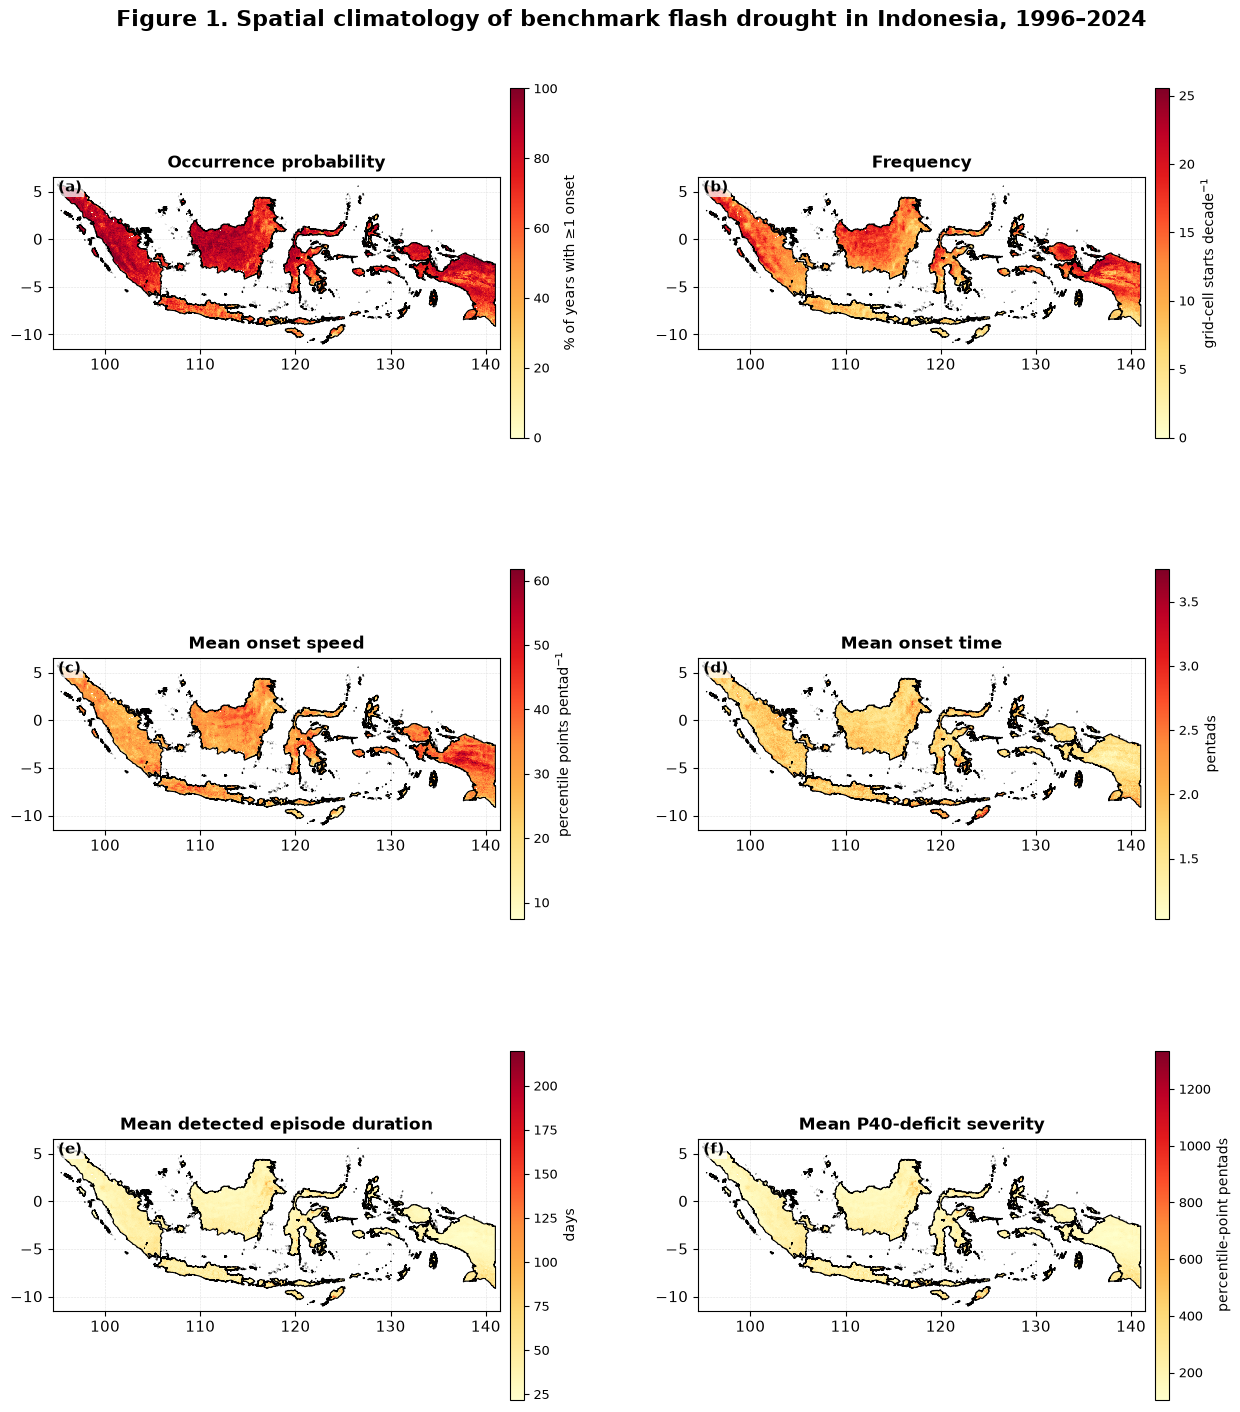

In [18]:
# ============================================================
# FIGURE 1 — Spatial climatology
# Revised layout: 3 rows × 2 columns
# ============================================================

fig = plt.figure(figsize=(13, 15))

panels = [
    (
        "occurrence_probability_percent",
        "Occurrence probability",
        "% of years with ≥1 onset",
        "a"
    ),
    (
        "events_per_decade",
        "Frequency",
        "grid-cell starts decade$^{-1}$",
        "b"
    ),
    (
        "mean_onset_speed_pp_per_pentad",
        "Mean onset speed",
        "percentile points pentad$^{-1}$",
        "c"
    ),
    (
        "mean_onset_time_pentads",
        "Mean onset time",
        "pentads",
        "d"
    ),
    (
        "mean_total_duration_days",
        "Mean detected episode duration",
        "days",
        "e"
    ),
    (
        "mean_severity_p40_pp_pentad",
        "Mean P40-deficit severity",
        "percentile-point pentads",
        "f"
    ),
]

# ------------------------------------------------------------
# 3 rows × 2 columns
# ------------------------------------------------------------
positions = [321, 322,
             323, 324,
             325, 326]

for pos, (var, title, label, letter) in zip(positions, panels):

    ax = setup_map_ax(fig, pos)

    im = map_mesh(
        ax,
        clim[var],
        cmap=CMAP_WARM
    )

    overlay_indonesia_boundary(ax)

    # Colorbar dibuat sedikit lebih besar agar mudah dibaca
    cb = fig.colorbar(
        im,
        ax=ax,
        pad=0.018,
        shrink=0.90,
        aspect=25
    )

    cb.set_label(
        label,
        fontsize=10
    )

    cb.ax.tick_params(
        labelsize=9
    )

    ax.set_title(
        title,
        fontsize=12,
        fontweight="bold",
        pad=7
    )

    panel_label(
        ax,
        f"({letter})"
    )

# ------------------------------------------------------------
# Main title
# ------------------------------------------------------------
fig.suptitle(
    "Figure 1. Spatial climatology of benchmark flash drought "
    "in Indonesia, 1996–2024",
    fontsize=16,
    fontweight="bold",
    y=0.985
)

# ------------------------------------------------------------
# Spacing
# ------------------------------------------------------------
fig.subplots_adjust(
    left=0.055,
    right=0.965,
    bottom=0.045,
    top=0.945,
    wspace=0.20,
    hspace=0.24
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
safe_savefig(
    fig,
    "Figure1_benchmark_climatology_3x2.png"
)

plt.show()